In [ ]:
# ==========================================
# 1. standard library imports 
# ==========================================
import os
import glob
import shutil
import zipfile
import warnings
import calendar
import urllib.request
import requests

# ==========================================
# 2. data analysis math thingies imports
# ==========================================
import numpy as np
import pandas as pd
import xarray as xr

# ==========================================
# 3. plotting imports
# ==========================================
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# suppress annoying warnings 
warnings.filterwarnings('ignore')

In [ ]:
# ==========================================
# 2. Regional filtering and download+ QC flags and filtering by number of cycles 
# ==========================================
# Format: "Region_Name": (lat_min, lat_max, lon_min, lon_max)
TARGET_REGIONS = {
    "Arabian_Sea": (5, 20, 50, 100),       # Your custom Lon limit (>=50E up to 100E)
    "Bay_of_Bengal": (5, 20, 80, 100),
    "Equatorial_IO": (-5, 5, 50, 100)
}

BASE_URL = "https://data-argo.ifremer.fr/dac"

def download_bioargo_data(index_df):
    """
    Loops through target ocean regions, filters the Argo index for quality 
    profiles (>20 cycles containing CHLA), and downloads the NetCDF files.
    """
    print("starting download pipeline...\n")
    
    for region_name, bounds in TARGET_REGIONS.items():
        lat_min, lat_max, lon_min, lon_max = bounds
        
        print(f"processing region: {region_name.replace('_', ' ')}")
        print(f"bounds: lat({lat_min} to {lat_max}), lon({lon_min} to {lon_max})")

        # 1. spatial & parameter filtering
        spatial_mask = (index_df['latitude'] >= lat_min) & (index_df['latitude'] <= lat_max) & \
                       (index_df['longitude'] >= lon_min) & (index_df['longitude'] <= lon_max)
        chl_mask = index_df['parameters'].str.contains('CHLA', na=False)
        
        region_df = index_df[spatial_mask & chl_mask].copy()
        
        if region_df.empty:
            print(f"whoops! no floats found matching criteria in {region_name}. Skipping.\n")
            continue
            
        # extract the WMO ID from the file path string
        region_df['wmo'] = region_df['file'].str.split('/').str[1]

        # 2. cycle no filter: only keep floats with >20 profiles/cycles
        profile_counts = region_df.groupby('wmo').size()
        frequent_floats = profile_counts[profile_counts > 20].index.tolist()
        
        print(f"found {len(profile_counts)} total floats. filters applied: CHLA present & >20 cycles.")
        print(f"{len(frequent_floats)} floats passed the quality check.")

        # 3. setup local storage (ignored by Git automatically via our planned .gitignore)
        download_dir = f"fixed_{region_name}_chl_bioargo"
        os.makedirs(download_dir, exist_ok=True)
        
        # lookup mapping each WMO to its respective DAC (Data Assembly Center) so we dont get random files from the pacific or smn accidently 
        wmo_to_dac = dict(zip(region_df['wmo'], region_df['file'].str.split('/').str[0]))

        # 4. download loop
        print(f"downloading NetCDF files to '{download_dir}'...")
        for wmo in sorted(frequent_floats):
            file_name = f"{wmo}_Sprof.nc"
            save_path = os.path.join(download_dir, file_name)

            # check if file is already downloaded so you dont spend 30 mins and eat storage again 
            if os.path.exists(save_path):
                continue

            dac = wmo_to_dac.get(wmo, 'coriolis')
            url = f"{BASE_URL}/{dac}/{wmo}/{file_name}"

            try:
                response = requests.get(url, stream=True, timeout=15)
                if response.status_code == 200:
                    with open(save_path, 'wb') as f:
                        for chunk in response.iter_content(chunk_size=8192):
                            f.write(chunk)
                    print(f"   + saved {file_name}")
                else:
                    print(f"   - failed {wmo} (Status Code: {response.status_code})")
            except Exception as e:
                print(f" whoops error fetching float {wmo}: {e}")
                
        print(f"yay done processing for {region_name}.\n" + "-"*50 + "\n")

In [ ]:
def extract_float_coordinates(folder_name):
    """
    reads all NetCDF files in a folder, calculates the mean position 
    (centroid) for each float, and returns a DataFrame.
    """
    # look for files inside wtv folder is saved as
    file_list = glob.glob(os.path.join(folder_name, "*.nc"))
    
    if not file_list:
        print(f"??No NetCDF files found in '{folder_name}'.")
        return pd.DataFrame()

    data = []
    for file in file_list:
        try:
            with xr.open_dataset(file) as ds:
                # extract WMO from the filename safely across different operating systems
                wmo_id = os.path.basename(file).split('_')[0]
                
                data.append({
                    'wmo': wmo_id,
                    'latitude': ds['LATITUDE'].values.mean(),
                    'longitude': ds['LONGITUDE'].values.mean()
                })
        except Exception as e:
            print(f" whoops could not read {os.path.basename(file)}: {e}")

    return pd.DataFrame(data)

In [ ]:
def plot_float_positions(coords_df, region_name, bounds):
    """
    plots the float centroids on a cartopy map for verification so all floats are in the right place
    and saves the image locally.
    """
    if coords_df.empty:
        print(f"?? no data to plot for {region_name}")
        return

    lon_min, lon_max, lat_min, lat_max = bounds

    # setup the Plot
    fig = plt.figure(figsize=(10, 7))
    ax = plt.axes(projection=ccrs.PlateCarree())

    # set dynamic map boundaries based on the region
    ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())

    # add geography
    ax.add_feature(cfeature.LAND, facecolor='lightgray', zorder=1)
    ax.add_feature(cfeature.COASTLINE, linewidth=1.5, zorder=2)

    # plot the float centroids
    plt.scatter(coords_df['longitude'], coords_df['latitude'],
                color='darkblue', s=50, alpha=0.8, transform=ccrs.PlateCarree(),
                label=f'{region_name.replace("_", " ")} Floats', zorder=3, edgecolors='white')

    # gridlines so you can see coordinates 
    gl = ax.gridlines(draw_labels=True, linestyle='--', alpha=0.5)
    gl.top_labels = False
    gl.right_labels = False

    # title and layout
    clean_title = region_name.replace("_", " ")
    plt.title(f'Argo Float Centroids in the {clean_title}', fontsize=14, pad=15)
    plt.legend(loc='lower left')
    
    # create a local directory for verification plots
    os.makedirs("plots", exist_ok=True)
    output_path = f"plots/{region_name}_centroids.png"
    
    # save locally to check your work. (Our .gitignore will hide this folder from GitHub!)
    plt.savefig(output_path, dpi=150, bbox_inches='tight')
    plt.close()
    print(f"yay verification plot saved locally to: {output_path}")

In [ ]:
# define the map limits for each region: (lon_min, lon_max, lat_min, lat_max)
PLOT_BOUNDS = {
    "Arabian_Sea": (50, 85, 5, 25),
    "Bay_of_Bengal": (80, 100, 5, 20),
    "Equatorial_IO": (50, 100, -5, 5)
}

# loop to run logic for all three regions
for region, map_limits in PLOT_BOUNDS.items():
    folder_path = f"fixed_{region}_chl_bioargo"
    
    print(f"\n📍 Extracting coordinates for {region}...")
    df_coords = extract_float_coordinates(folder_path)
    
    print(f"🎨 Generating map for {region}...")
    plot_float_positions(df_coords, region, map_limits)

In [ ]:
def calculate_regional_climatology(base_dir, region_name):
    """
    loads regional NetCDF files, filters by quality control masks, 
    interpolates data onto a standard depth grid, calculates monthly 
    climatologies, and exports a CSV file.
    """
    print(f"starting processing pipeline for: {region_name}")
    
    # define standard vertical pressure (depth) grid 
    # steps: 0-200m every 5m, and 250m-2000m every 50m
    std_grid = np.concatenate([np.arange(0, 205, 5), np.arange(250, 2050, 50)])
    
    # initialize dictionary to collect profile lists for months Jan (1) to Dec (12)
    monthly_data = {month: [] for month in range(1, 13)}
    
    # get all .nc files inside the specified directory
    file_list = glob.glob(os.path.join(base_dir, "*.nc"))
    if not file_list:
        print(f"?? no NetCDF files found in {base_dir}. skipping region.")
        return

    for file_path in file_list:
        try:
            with xr.open_dataset(file_path, decode_times=True) as ds:
                # 1. extract post-calibration scientific adjusted variables
                chla = ds['CHLA_ADJUSTED'].values.copy()
                pres = ds['PRES_ADJUSTED'].values
                qc = ds['CHLA_ADJUSTED_QC'].values.astype(str)
                time = ds['JULD'].values

                # 2. quality control (QC) masking
                # keep data flagged as: 1 (Good), 2 (Probably Good), 5 (Value Changed), 8 (Estimated)
                valid_qc_mask = np.isin(qc, ['1', '2', '5', '8'])
                chla[~valid_qc_mask] = np.nan
                chla[chla <= 0] = np.nan  # drop unphysical zero or negative values and dont treat as zero or they mess w climatology means

                # 3. iterate through individual profiles (N_PROF)
                for i in range(ds.dims['N_PROF']):
                    month = pd.to_datetime(time[i]).month
                    p_levels = pres[i, :]
                    c_levels = chla[i, :]

                    # only interpolate if we have enough physical data points
                    if np.sum(~np.isnan(c_levels)) > 3:
                        # map uneven sensor readings cleanly onto our standard vertical grid
                        interp_c = np.interp(std_grid, p_levels, c_levels, left=np.nan, right=np.nan)
                        monthly_data[month].append(interp_c)
                        
        except Exception as e:
            print(f"   ⚠️ Skipping file {os.path.basename(file_path)} due to error: {e}")

    # 4. compute monthly means across our standard depth grid rows
    monthly_means = {}
    for month in range(1, 13):
        data_matrix = monthly_data[month]
        if data_matrix:
            monthly_means[month] = np.nanmean(data_matrix, axis=0)
        else:
            # if a month has zero data, fill it with NaNs so the DataFrame matches grid size
            monthly_means[month] = np.zeros(len(std_grid)) * np.nan

    # 5. build final DataFrame and export climatology dataset
    df_climatology = pd.DataFrame(monthly_means, index=std_grid)
    df_climatology.index.name = 'Depth_Pressure_dbar'
    
    output_filename = f"{region_name}_Climatology.csv"
    df_climatology.to_csv(output_filename)
    
    print(f"dones monthly climatology saved to: {output_filename}\n" + "="*50)

In [ ]:
# map regions directly to the clean folder structures we created before 
REGIONS_CONFIG = {
    "Arabian_Sea": "fixed_Arabian_Sea_chl_bioargo",
    "Bay_of_Bengal": "fixed_Bay_of_Bengal_chl_bioargo",
    "Equatorial_IO": "fixed_Equatorial_IO_chl_bioargo"
}

# run the calculation for all regions 
for region, directory in REGIONS_CONFIG.items():
    calculate_regional_climatology(directory, region)

In [ ]:
def calculate_sst_climatology(file_path):
    """
    loads the global NOAA OISST NetCDF file, slices it into the 3 target 
    ocean basins, computes the regional spatial averages, and returns 
    a single compiled DataFrame for all regions.
    """
    print("loading local NOAA OISST dataset...")
    if not os.path.exists(file_path):
        print(f"error: {file_path} not found. please download.")
        return pd.DataFrame()
        
    ds = xr.open_dataset(file_path)

    # define your specific regions 
    regions_config = {
        "Arabian_Sea": {"lat": (5, 25), "lon": (50, 75)},
        "Bay_of_Bengal": {"lat": (5, 22), "lon": (80, 100)},
        "Equatorial_IO": {"lat": (-5, 5), "lon": (60, 90)}
    }

    sst_results = {}

    print("Slicing and calculating monthly means across target basins...")
    for name, bounds in regions_config.items():
        lat_min, lat_max = bounds["lat"]
        lon_min, lon_max = bounds["lon"]

        # safety Check: handle descending latitudes (89.5 down to -89.5) gracefully
        if ds.lat.values[0] > ds.lat.values[-1]:
            lat_slice = slice(lat_max, lat_min)
        else:
            lat_slice = slice(lat_min, lat_max)

        # subset data to region
        ds_region = ds.sel(lat=lat_slice, lon=slice(lon_min, lon_max))

        # calculate space mean, then aggregate by month to build a long-term climatology
        spatial_mean = ds_region['sst'].mean(dim=['lat', 'lon'])
        monthly_clim = spatial_mean.groupby('time.month').mean('time').values

        sst_results[name] = monthly_clim

    # format output into a clean, presentation-ready dataset
    months_labels = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
    df_sst = pd.DataFrame(sst_results, index=months_labels)
    df_sst.index.name = 'Month'
    
    return df_sst

In [ ]:
def plot_final_climatology_grid(df_sst):
    """
    generates a 12x3 matrix subplot displaying vertical Chlorophyll profiles 
    from 0-300m and correlates it with NOAA SST averages for all regions.
    saves the final plot locally under the 'plots' directory.
    """
    print("constructing the 12x3 Chlorophyll-SST matrix plot...")
    
    # map directly to the CSV files created by your script
    regions_files = {
        "Arabian Sea": "Arabian_Sea_Climatology.csv",
        "Bay of Bengal": "Bay_of_Bengal_Climatology.csv",
        "Equatorial IO": "Equatorial_IO_Climatology.csv"
    }

    months_str = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
    global_chl_max = 0.0
    loaded_dfs = {}

    # pre-load files and isolate maximum value within upper 300m limits for universal scaling
    for region_name, filename in regions_files.items():
        if os.path.exists(filename):
            df = pd.read_csv(filename, index_col=0)
            df.index = pd.to_numeric(df.index)
            loaded_dfs[region_name] = df

            upper_300m_df = df.loc[df.index <= 300]
            if not upper_300m_df.empty:
                max_val = upper_300m_df.max().max()
                if max_val > global_chl_max:
                    global_chl_max = max_val

    # lock global X scale with a padding margin
    x_max_limit = global_chl_max * 1.1 if global_chl_max > 0 else 2.0

    fig, axes = plt.subplots(12, 3, figsize=(18, 40), constrained_layout=True)

    for row_idx, month_name in enumerate(months_str):
        col_name = str(row_idx + 1)  # Months columns are labeled '1' through '12'

        for col_idx, (region_name, _) in enumerate(regions_files.items()):
            ax = axes[row_idx, col_idx]

            if region_name in loaded_dfs:
                df = loaded_dfs[region_name]

                if col_name in df.columns:
                    data = df[[col_name]].dropna()
                    x = data[col_name].values
                    y = data.index.values

                    ax.plot(x, y, color='darkgreen', linewidth=1.5)

                    if len(x) > 0:
                        max_idx = np.argmax(x)
                        dcm_depth = y[max_idx]
                        plot_depth = 5 if dcm_depth == 0 else dcm_depth
                        ax.axhline(y=plot_depth, color='darkgreen', linestyle='--', alpha=0.8, linewidth=1.5)

            # uniform axes formatting across the whole subplot matrix
            ax.set_ylim(300, 0) # Focus on upper 300 meters
            ax.set_xlim(0, x_max_limit)

            ax.xaxis.set_ticks_position('top')
            ax.xaxis.set_label_position('top')
            ax.set_xlabel('Chl-a (mg/m³)')
            ax.grid(True, linestyle=':', alpha=0.5)

            if col_idx == 0:
                ax.set_ylabel('Depth (m)')
                ax.text(-0.35, 0.5, month_name, transform=ax.transAxes,
                        fontsize=12, fontweight='bold', rotation=90, va='center')

            if region_name in df_sst.columns:
                sst_val = df_sst.loc[month_name, region_name]
                ax.text(0.95, 0.95, f'SST: {sst_val:.1f}°C',
                        transform=ax.transAxes, fontsize=10, fontweight='bold',
                        ha='right', va='top', bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))

            if row_idx == 0:
                ax.set_title(region_name, fontsize=14, fontweight='bold', pad=30)

    # save to 'plots/' folder
    os.makedirs("plots", exist_ok=True)
    output_img_path = "plots/Master_Climatology_Profiles.png"
    plt.savefig(output_img_path, dpi=120, bbox_inches='tight')
    plt.close()
    print(f" Master validation profile matrix saved to: {output_img_path}")

In [ ]:
# =====================================================================
# 3. PIPELINE EXECUTION 
# =====================================================================
if __name__ == "__main__":
    
    # ---- STEP A: download and map argo floats ----
    print(" Fetching the global Argo bio-profile index...")
    index_url = "https://data-argo.ifremer.fr/argo_bio-profile_index.txt.gz"
    global_df = pd.read_csv(index_url, skiprows=8)
    
    download_bioargo_data(global_df)

    # ---- STEP B: extract coordinates & map locations ----
    for region, map_limits in PLOT_BOUNDS.items():
        folder_path = f"fixed_{region}_chl_bioargo"
        df_coords = extract_float_coordinates(folder_path)
        plot_float_positions(df_coords, region, map_limits)
    print(" local coordinate checks and maps generated inside 'plots/' folder.")

    # ---- STEP C: calculate profile climatology ----
    for region in TARGET_REGIONS.keys():
        calculate_regional_climatology(f"fixed_{region}_chl_bioargo", region)

    # ---- STEP D: calculate sea surface temperature climatology ----
    noaa_url = "https://downloads.psl.noaa.gov/Datasets/noaa.oisst.v2/sst.mnmean.nc"
    local_sst_file = "sst.mnmean.nc"
    if not os.path.exists(local_sst_file):
        print("local NOAA OISST file missing. starting download...")
        urllib.request.urlretrieve(noaa_url, local_sst_file)
    
    df_sst_final = calculate_sst_climatology(local_sst_file)
    df_sst_final.to_csv("regional_SST_climatology.csv")

    # ---- STEP E: generate the plots grid ----
    # re-naming columns of df_sst_final to match exact layout keys ("Arabian Sea" instead of "Arabian_Sea")
    df_sst_plotting = df_sst_final.rename(columns={
        "Arabian_Sea": "Arabian Sea",
        "Bay_of_Bengal": "Bay of Bengal",
        "Equatorial_IO": "Equatorial IO"
    })
    plot_final_climatology_grid(df_sst_plotting)
    
    print("\ndonedonedone")f

In [ ]:


# Configuration
INCLUDE_FLAG_3 = True
region_name = "Arabian_Sea"
base_dir = "fixed Arabian Sea chl bioargo" # The folder we just verified
output_dir = "climatology_expanded"
os.makedirs(output_dir, exist_ok=True)

std_grid = np.concatenate([np.arange(0, 205, 5), np.arange(250, 2050, 50)])
monthly_data = {month: [] for month in range(1, 13)}

print(f"--- Processing {region_name} (Mode: {'Expanded' if INCLUDE_FLAG_3 else 'Strict'}) ---")

for file in os.listdir(base_dir):
    if not file.endswith(".nc"): continue

    try:
        with xr.open_dataset(os.path.join(base_dir, file), decode_times=True) as ds:
            chla = ds['CHLA_ADJUSTED'].values
            pres = ds['PRES_ADJUSTED'].values
            qc = ds['CHLA_ADJUSTED_QC'].values.astype(str)
            time = ds['JULD'].values

            # QC Filter including Flag 3
            accepted_flags = ['1', '2', '3', '5', '8'] if INCLUDE_FLAG_3 else ['1', '2', '5', '8']
            mask = np.isin(qc, accepted_flags)

            chla[~mask] = np.nan
            chla[chla <= 0] = np.nan

            for i in range(ds.dims['N_PROF']):
                month = pd.to_datetime(time[i]).month
                p = pres[i, :]
                c = chla[i, :]

                if np.sum(~np.isnan(c)) > 3:
                    interp_c = np.interp(std_grid, p, c, left=np.nan, right=np.nan)
                    monthly_data[month].append(interp_c)
    except Exception as e:
        print(f"Skipping {file}: {e}")

# Calculate and Save
monthly_means = {m: np.nanmean(data, axis=0) if data else np.zeros(len(std_grid))*np.nan
                 for m, data in monthly_data.items()}

df = pd.DataFrame(monthly_means, index=std_grid)
df.to_csv(f"{output_dir}/{region_name}_Climatology.csv")
print(f"--- Completed {region_name}. File saved to {output_dir}/ ---")

--- Processing Arabian_Sea (Mode: Expanded) ---


/tmp/ipykernel_548/1754419603.py:35: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  for i in range(ds.dims['N_PROF']):
/tmp/ipykernel_548/1754419603.py:35: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  for i in range(ds.dims['N_PROF']):
/tmp/ipykernel_548/1754419603.py:35: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  for i in range(ds.dims['N_PROF']):
/tmp/ipykernel_548/1754419603.py:35: Fut

--- Completed Arabian_Sea. File saved to climatology_expanded/ ---


/tmp/ipykernel_548/1754419603.py:35: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  for i in range(ds.dims['N_PROF']):


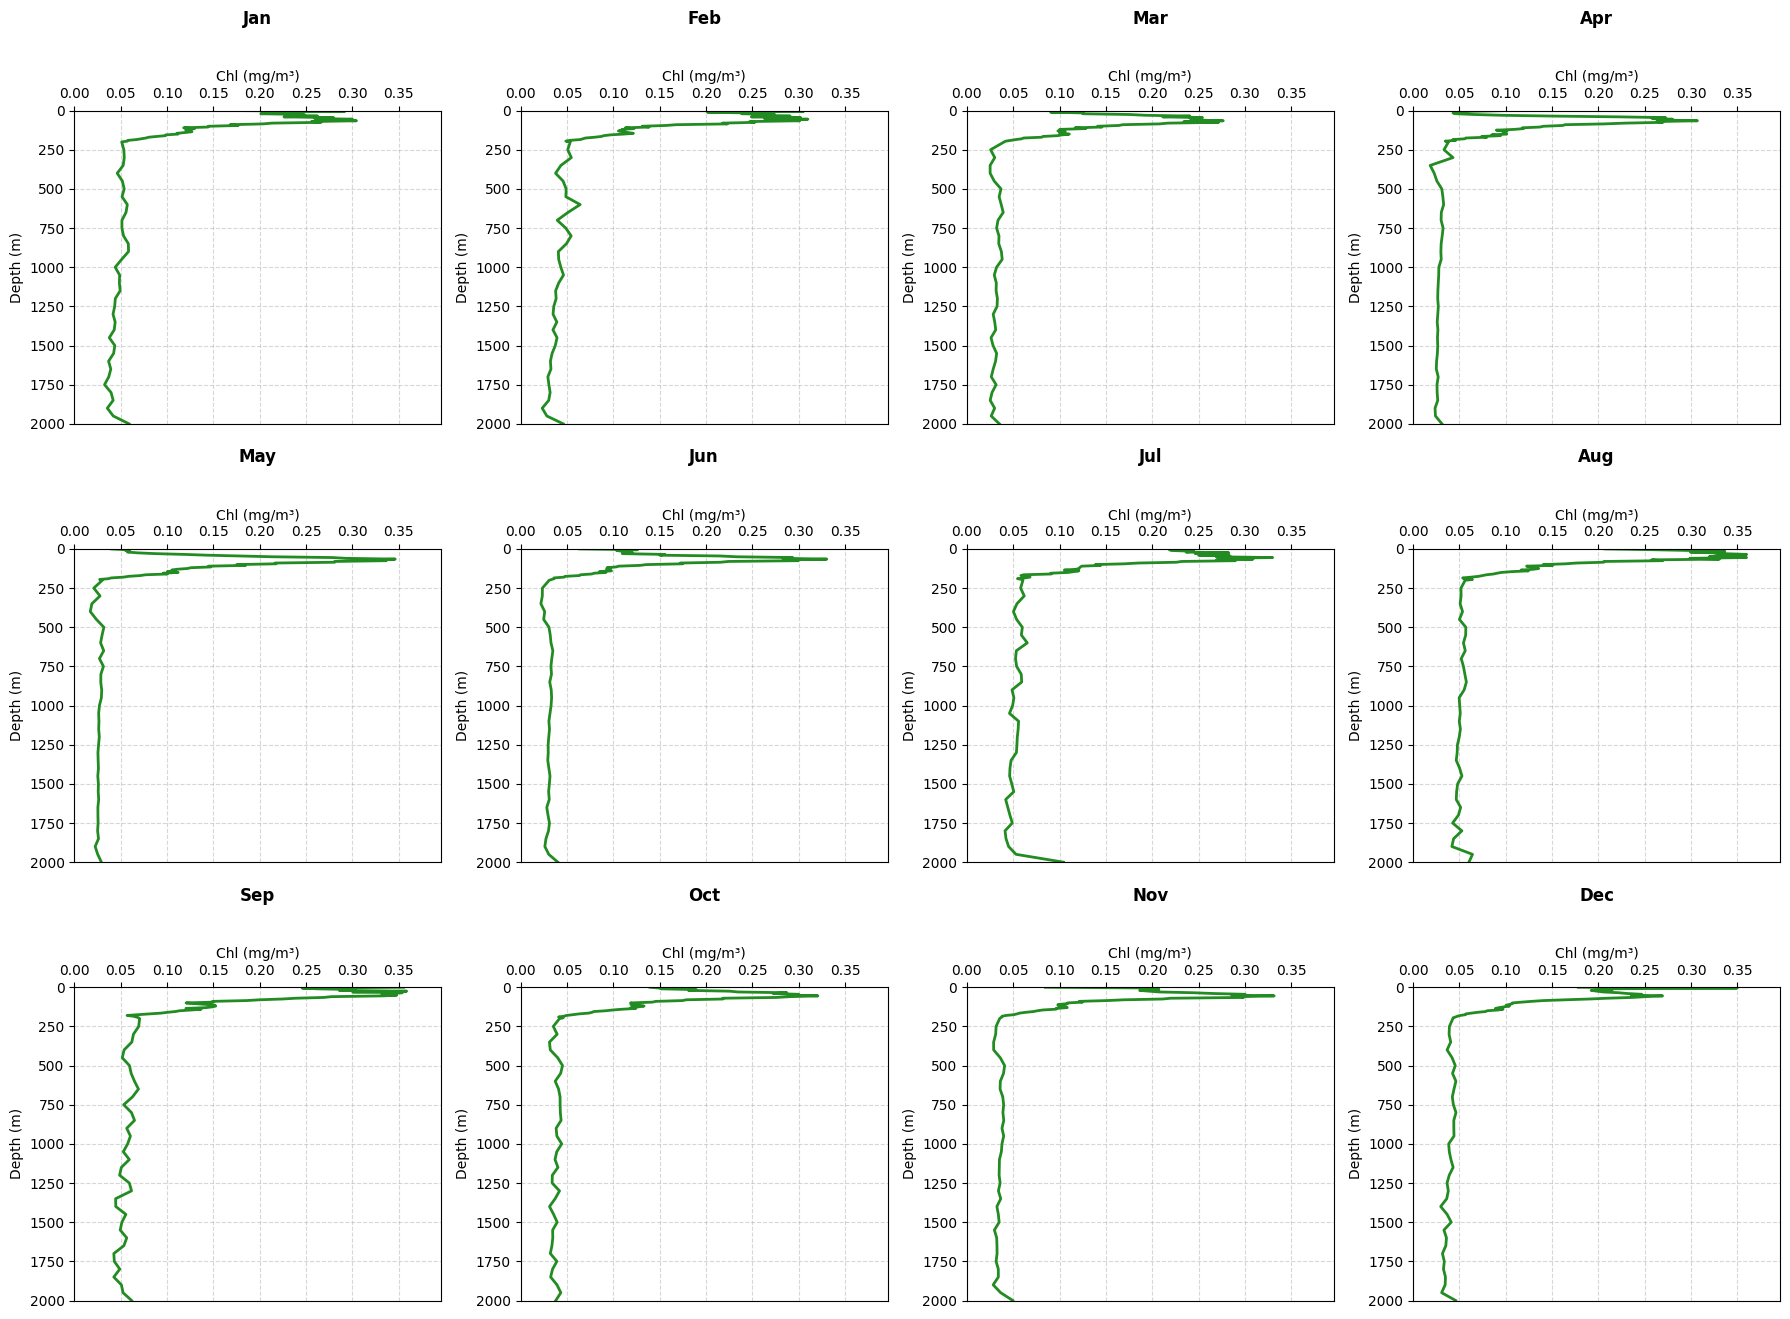

In [ ]:



# Load your data
df = pd.read_csv("climatology_expanded/Arabian_Sea_Climatology.csv", index_col=0)

# Define the professional green color and constant scale
prof_green = '#228B22'
x_max = df.max().max() * 1.1

# Setup the 3x4 grid - sharex and sharey are now False
fig, axes = plt.subplots(3, 4, figsize=(18, 14), sharex=False, sharey=False)
axes = axes.flatten()

for i in range(12):
    ax = axes[i]
    month_num = i + 1
    month_name = calendar.month_abbr[month_num]

    # Plot data
    ax.plot(df[str(month_num)], df.index, color=prof_green, linewidth=2)

    # Top X-axis configuration
    ax.xaxis.set_label_position('top')
    ax.xaxis.tick_top()
    ax.set_xlabel('Chl (mg/m³)')
    ax.set_xlim(0, x_max)

    # Force Y-axis scale and label on EVERY plot
    ax.set_ylabel('Depth (m)')
    ax.set_ylim(df.index.max(), 0) # Depth 0 at top

    # Ensure ticks are visible
    ax.tick_params(axis='both', which='both', top=True, labeltop=True, left=True, labelleft=True)

    # Set title and grid
    ax.set_title(f"{month_name}", y=1.25, fontweight='bold')
    ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

In [ ]:


# Define the paths
old_name = "climatology_expanded/Arabian_Sea_Climatology.csv"
new_name = "climatology_expanded/Arabian_Sea_Climatology_Flag3.csv"

# Check if the file exists and rename it
if os.path.exists(old_name):
    os.rename(old_name, new_name)
    print(f"Successfully renamed to: {new_name}")
else:
    print(f"Error: {old_name} not found. Ensure your script ran correctly.")

Successfully renamed to: climatology_expanded/Arabian_Sea_Climatology_Flag3.csv


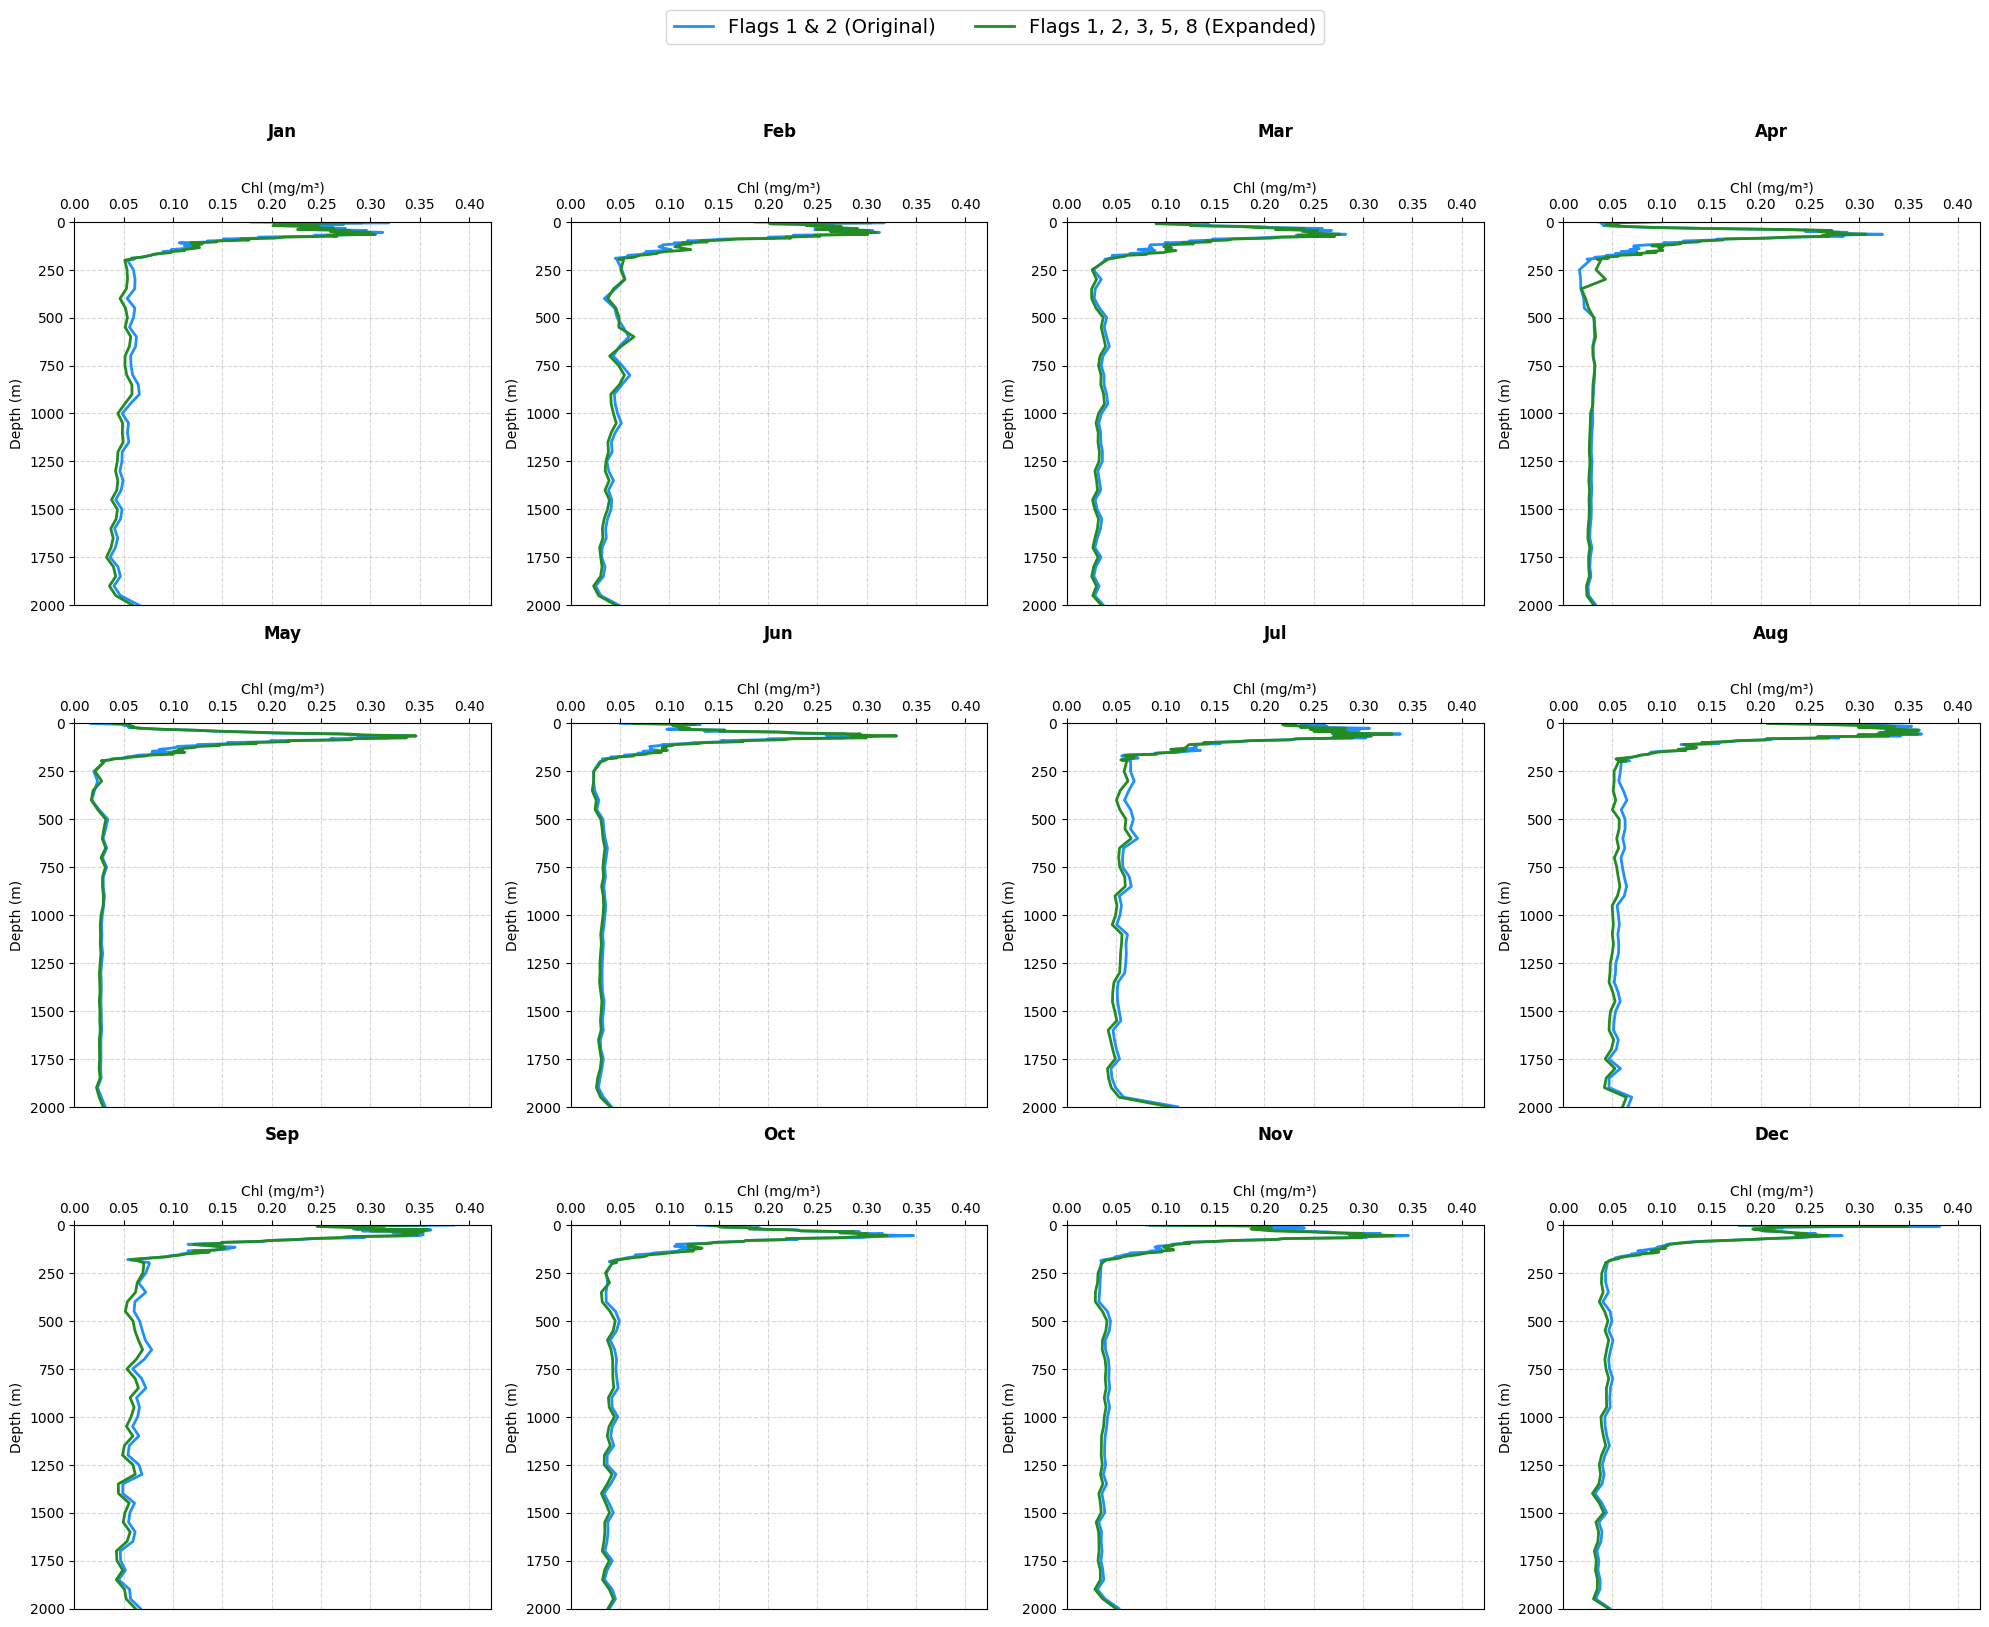

In [ ]:

# 1. Load the datasets
df_f3 = pd.read_csv("climatology_expanded/Arabian_Sea_Climatology_Flag3.csv", index_col=0)
df_orig = pd.read_csv("/content/Arabian_Sea_Climatology.csv", index_col=0)

# 2. Define colors
# Using distinct, color-blind friendly professional colors
color_f3 = '#228B22'   # Forest Green
color_orig = '#1E90FF' # Dodger Blue

x_max = max(df_f3.max().max(), df_orig.max().max()) * 1.1

# 3. Setup the 3x4 grid
fig, axes = plt.subplots(3, 4, figsize=(20, 16), sharex=False, sharey=False)
axes = axes.flatten()

for i in range(12):
    ax = axes[i]
    month_num = i + 1
    month_name = calendar.month_abbr[month_num]

    # Plot both datasets with specific labels
    ax.plot(df_orig[str(month_num)], df_orig.index, color=color_orig, label='Flags 1 & 2', linewidth=2)
    ax.plot(df_f3[str(month_num)], df_f3.index, color=color_f3, label='Flags 1, 2, 3, 5, 8', linewidth=2)

    # Axis configuration
    ax.xaxis.set_label_position('top')
    ax.xaxis.tick_top()
    ax.set_xlabel('Chl (mg/m³)')
    ax.set_ylabel('Depth (m)')
    ax.set_xlim(0, x_max)
    ax.set_ylim(df_f3.index.max(), 0)

    ax.tick_params(axis='both', which='both', top=True, labeltop=True, left=True, labelleft=True)
    ax.set_title(f"{month_name}", y=1.2, fontweight='bold')
    ax.grid(True, linestyle='--', alpha=0.5)

# 4. Add a single global legend at the top
fig.legend(labels=['Flags 1 & 2 (Original)', 'Flags 1, 2, 3, 5, 8 (Expanded)'],
           loc='upper center',
           bbox_to_anchor=(0.5, 1.02),
           ncol=2,
           fontsize=14,
           frameon=True)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

In [ ]:


# Update these names if your files have different spellings
files_to_extract = ['bob_data.zip', 'equatorial_data.zip']

for file in files_to_extract:
    if os.path.exists(file):
        print(f"Extracting {file}...")
        with zipfile.ZipFile(file, 'r') as zip_ref:
            zip_ref.extractall(".")
            # List folders to confirm extraction
            folders = [f for f in os.listdir(".") if os.path.isdir(f)]
            print(f"Extracted. Current folders: {folders}")
    else:
        print(f"File {file} not found. Please upload it to the Colab sidebar.")

Extracting bob_data.zip...
Extracted. Current folders: ['.config', '.ipynb_checkpoints', 'fixed Bay_of_Bengal chl bioargo', 'fixed Arabian Sea chl bioargo', 'climatology_expanded', 'sample_data']
Extracting equatorial_data.zip...
Extracted. Current folders: ['.config', '.ipynb_checkpoints', 'fixed Bay_of_Bengal chl bioargo', 'fixed Arabian Sea chl bioargo', 'climatology_expanded', 'fixed Equatorial_IO chl bioargo', 'sample_data']


In [ ]:


# Configuration
INCLUDE_FLAG_3 = True
output_dir = "climatology_expanded"
os.makedirs(output_dir, exist_ok=True)

# Define your regions mapping.
# UPDATE the values below if your unzipped folder names look slightly different!
regions = {
    "Arabian_Sea": "fixed Arabian Sea chl bioargo",
    "Bay_of_Bengal": "fixed Bay_of_Bengal chl bioargo", # Double check this folder name
    "Equatorial_IO": "fixed Equatorial_IO chl bioargo"   # Double check this folder name
}

std_grid = np.concatenate([np.arange(0, 205, 5), np.arange(250, 2050, 50)])

for region_name, base_dir in regions.items():
    if not os.path.exists(base_dir):
        print(f"Skipping {region_name}: Folder '{base_dir}' not found.")
        continue

    print(f"--- Processing {region_name} (Mode: Flag 3 Included) ---")
    monthly_data = {month: [] for month in range(1, 13)}

    for file in os.listdir(base_dir):
        if not file.endswith(".nc"): continue

        try:
            with xr.open_dataset(os.path.join(base_dir, file), decode_times=True) as ds:
                chla = ds['CHLA_ADJUSTED'].values
                pres = ds['PRES_ADJUSTED'].values
                qc = ds['CHLA_ADJUSTED_QC'].values.astype(str)
                time = ds['JULD'].values

                accepted_flags = ['1', '2', '3', '5', '8']
                mask = np.isin(qc, accepted_flags)

                chla[~mask] = np.nan
                chla[chla <= 0] = np.nan

                for i in range(ds.dims['N_PROF']):
                    month = pd.to_datetime(time[i]).month
                    p = pres[i, :]
                    c = chla[i, :]

                    if np.sum(~np.isnan(c)) > 3:
                        interp_c = np.interp(std_grid, p, c, left=np.nan, right=np.nan)
                        monthly_data[month].append(interp_c)
        except Exception as e:
            print(f"Skipping file {file} in {region_name}: {e}")

    # Calculate means and export
    monthly_means = {m: np.nanmean(data, axis=0) if data else np.zeros(len(std_grid))*np.nan
                     for m, data in monthly_data.items()}

    df = pd.DataFrame(monthly_means, index=std_grid)
    output_file = f"{output_dir}/{region_name}_Climatology_Flag3.csv"
    df.to_csv(output_file)
    print(f"Successfully saved: {output_file}\n")

--- Processing Arabian_Sea (Mode: Flag 3 Included) ---


/tmp/ipykernel_548/3030581666.py:45: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  for i in range(ds.dims['N_PROF']):
/tmp/ipykernel_548/3030581666.py:45: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  for i in range(ds.dims['N_PROF']):
/tmp/ipykernel_548/3030581666.py:45: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  for i in range(ds.dims['N_PROF']):
/tmp/ipykernel_548/3030581666.py:45: Fut

Successfully saved: climatology_expanded/Arabian_Sea_Climatology_Flag3.csv

--- Processing Bay_of_Bengal (Mode: Flag 3 Included) ---


/tmp/ipykernel_548/3030581666.py:45: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  for i in range(ds.dims['N_PROF']):
/tmp/ipykernel_548/3030581666.py:45: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  for i in range(ds.dims['N_PROF']):
/tmp/ipykernel_548/3030581666.py:45: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  for i in range(ds.dims['N_PROF']):
/tmp/ipykernel_548/3030581666.py:45: Fut

Successfully saved: climatology_expanded/Bay_of_Bengal_Climatology_Flag3.csv

--- Processing Equatorial_IO (Mode: Flag 3 Included) ---


/tmp/ipykernel_548/3030581666.py:45: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  for i in range(ds.dims['N_PROF']):
/tmp/ipykernel_548/3030581666.py:45: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  for i in range(ds.dims['N_PROF']):
/tmp/ipykernel_548/3030581666.py:45: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  for i in range(ds.dims['N_PROF']):
/tmp/ipykernel_548/3030581666.py:45: Fut

Successfully saved: climatology_expanded/Equatorial_IO_Climatology_Flag3.csv



/tmp/ipykernel_548/3030581666.py:45: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  for i in range(ds.dims['N_PROF']):


Generating comparison plot for Arabian_Sea...


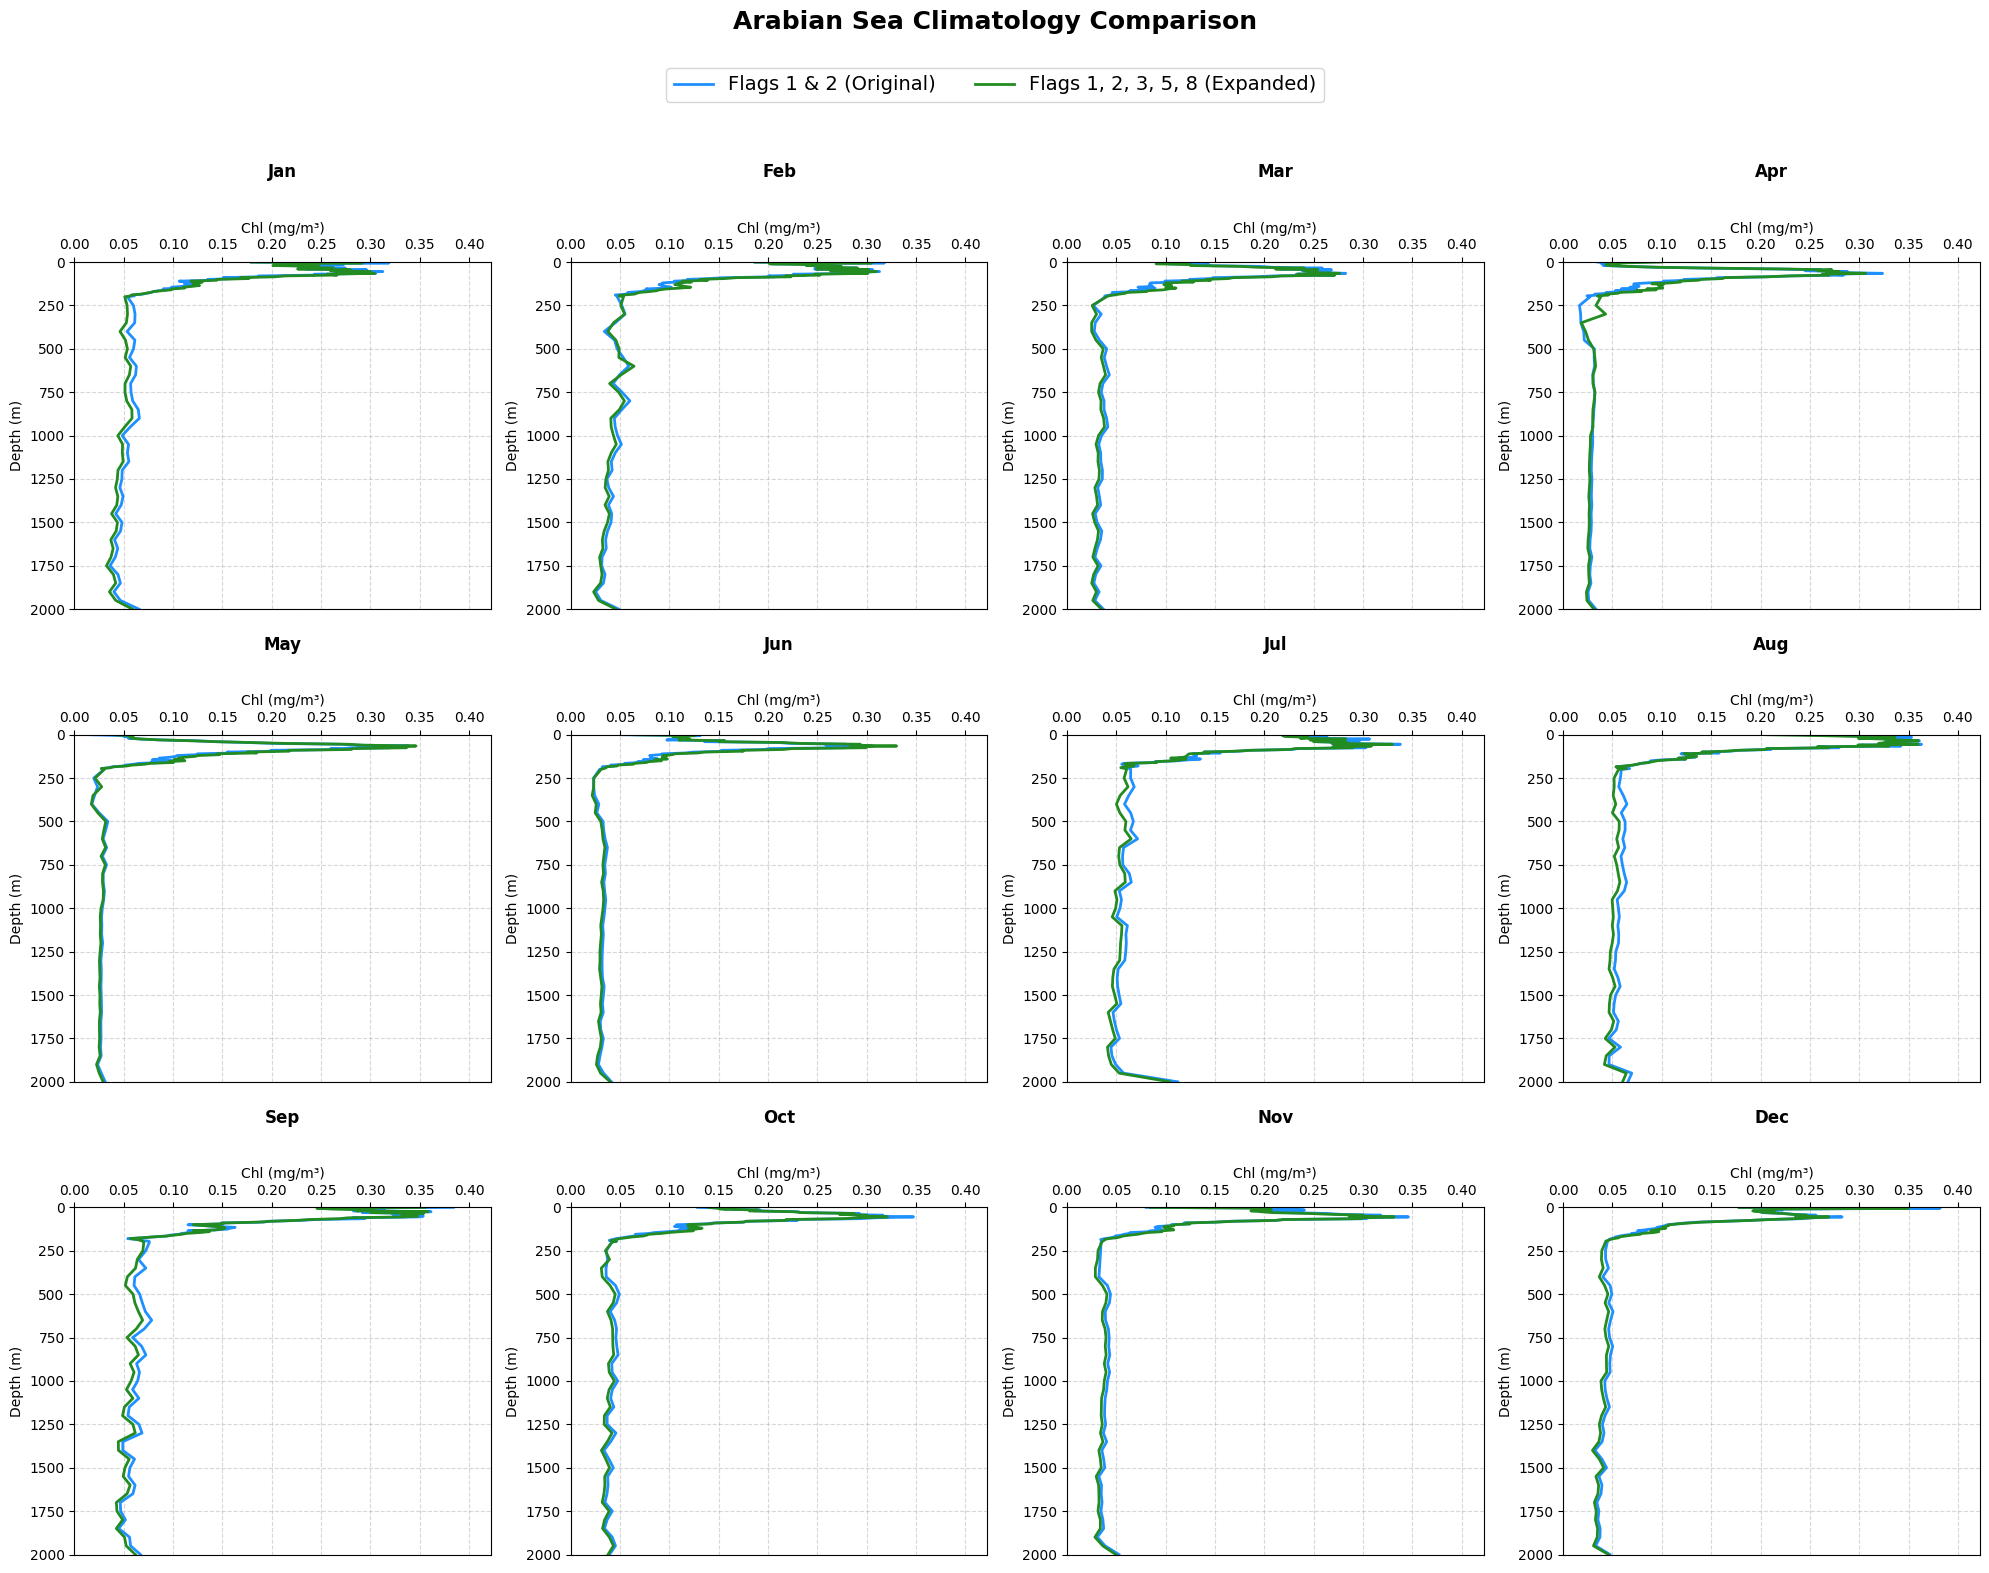

--------------------------------------------------
Generating comparison plot for Bay_of_Bengal...


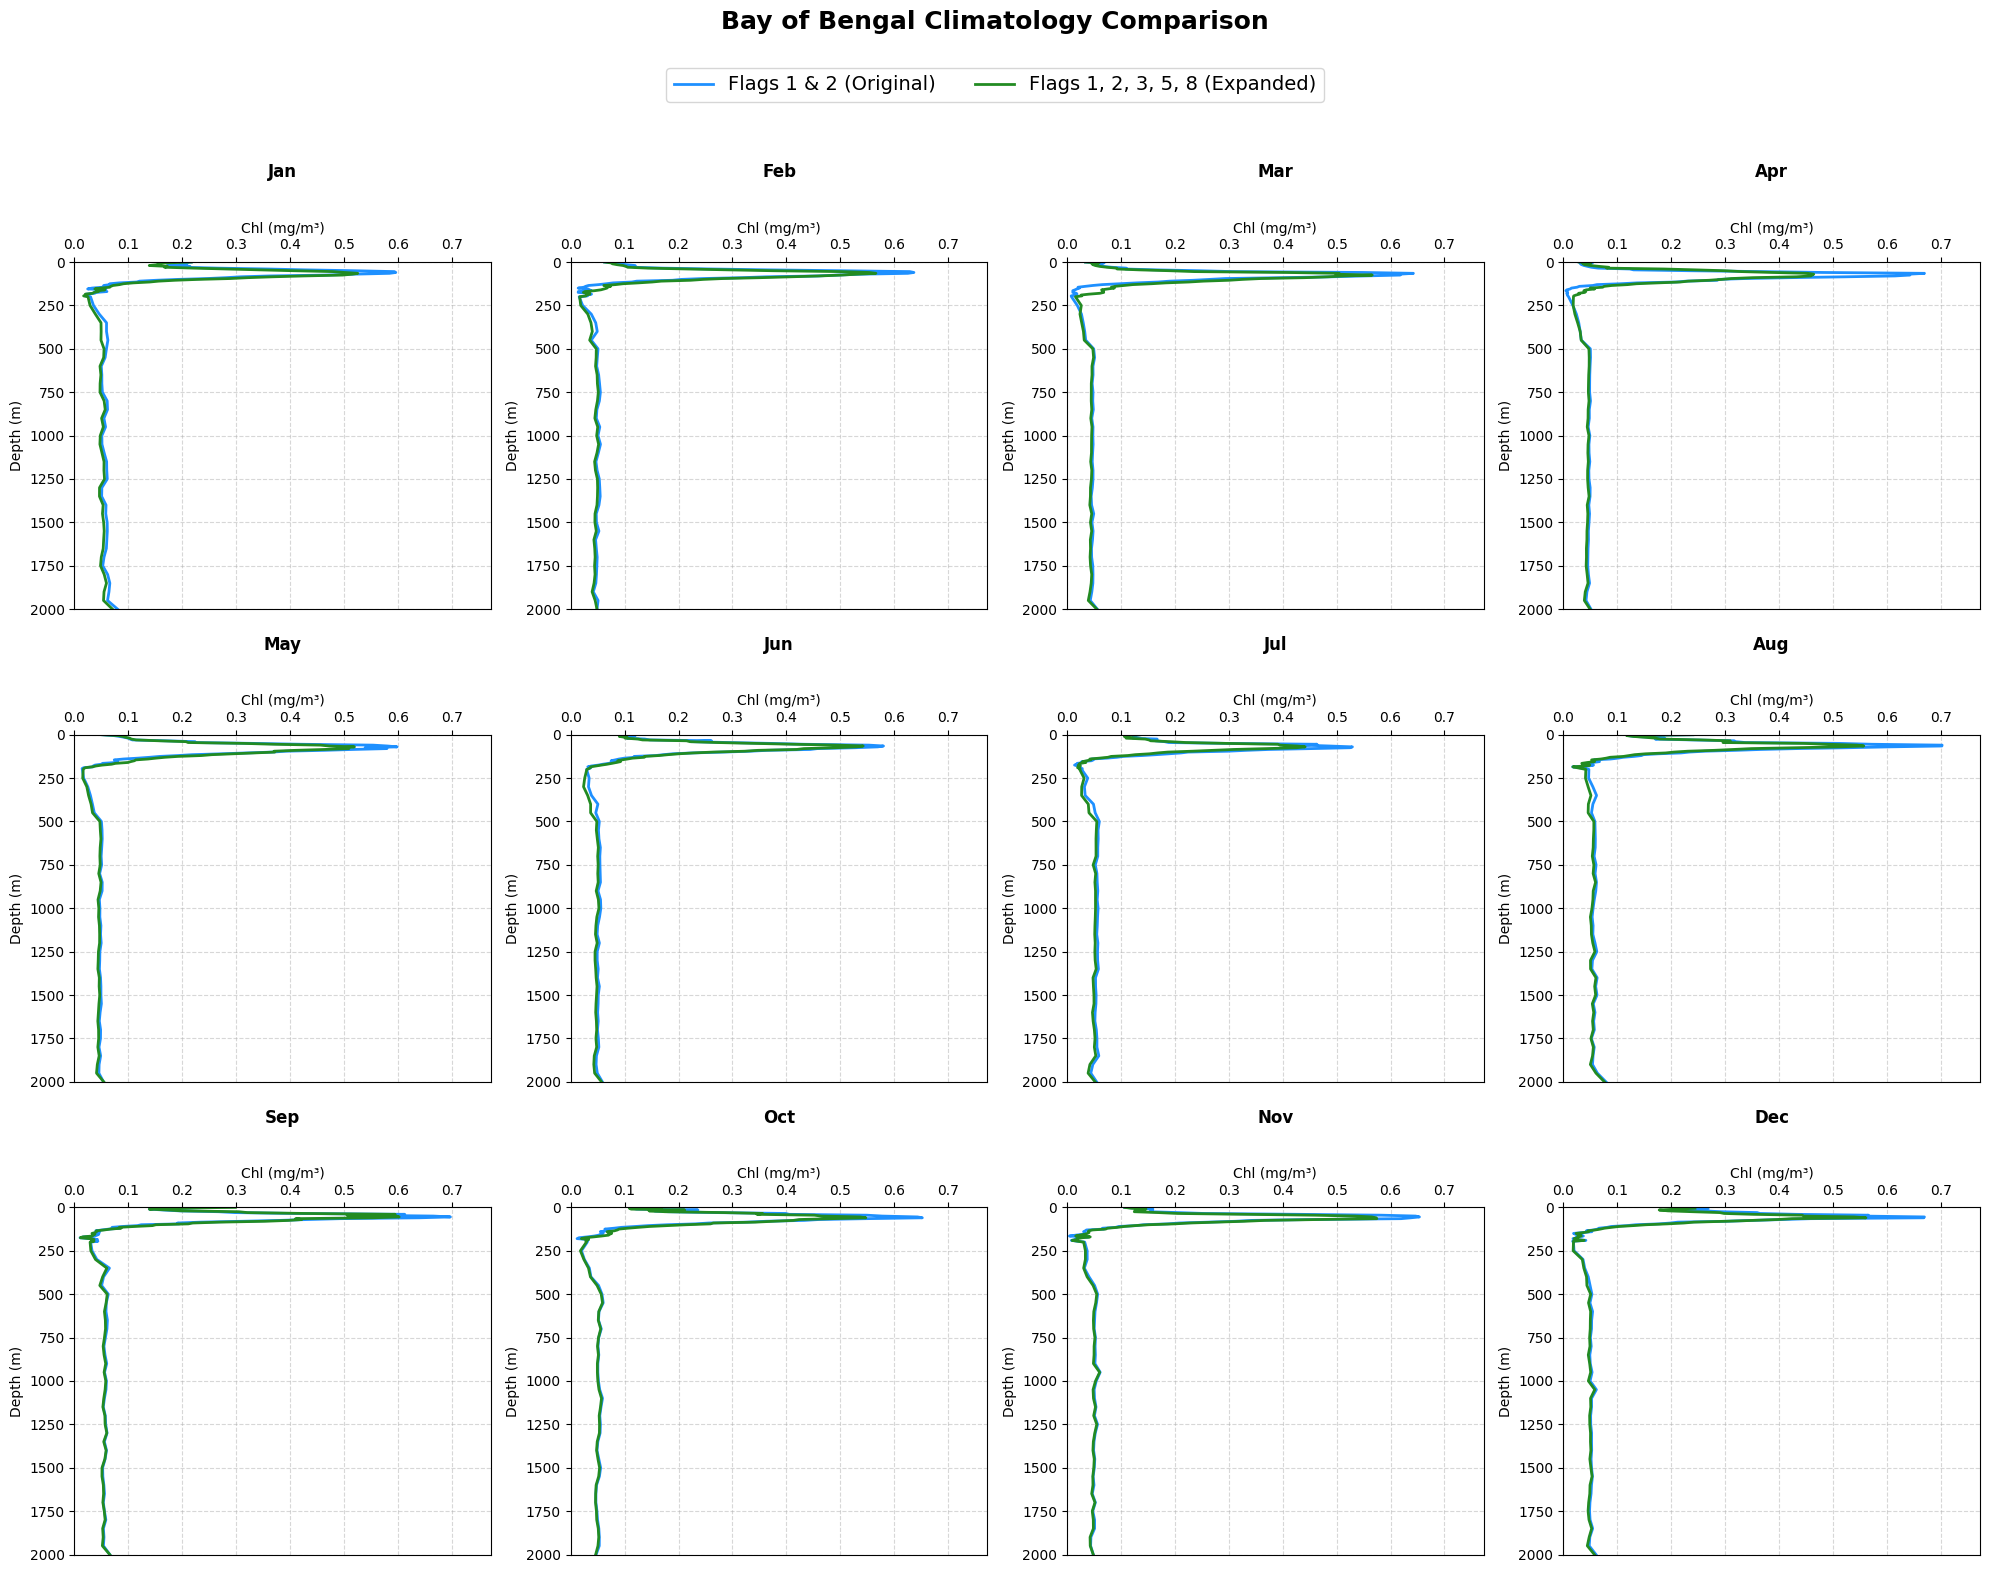

--------------------------------------------------
Generating comparison plot for Equatorial_IO...


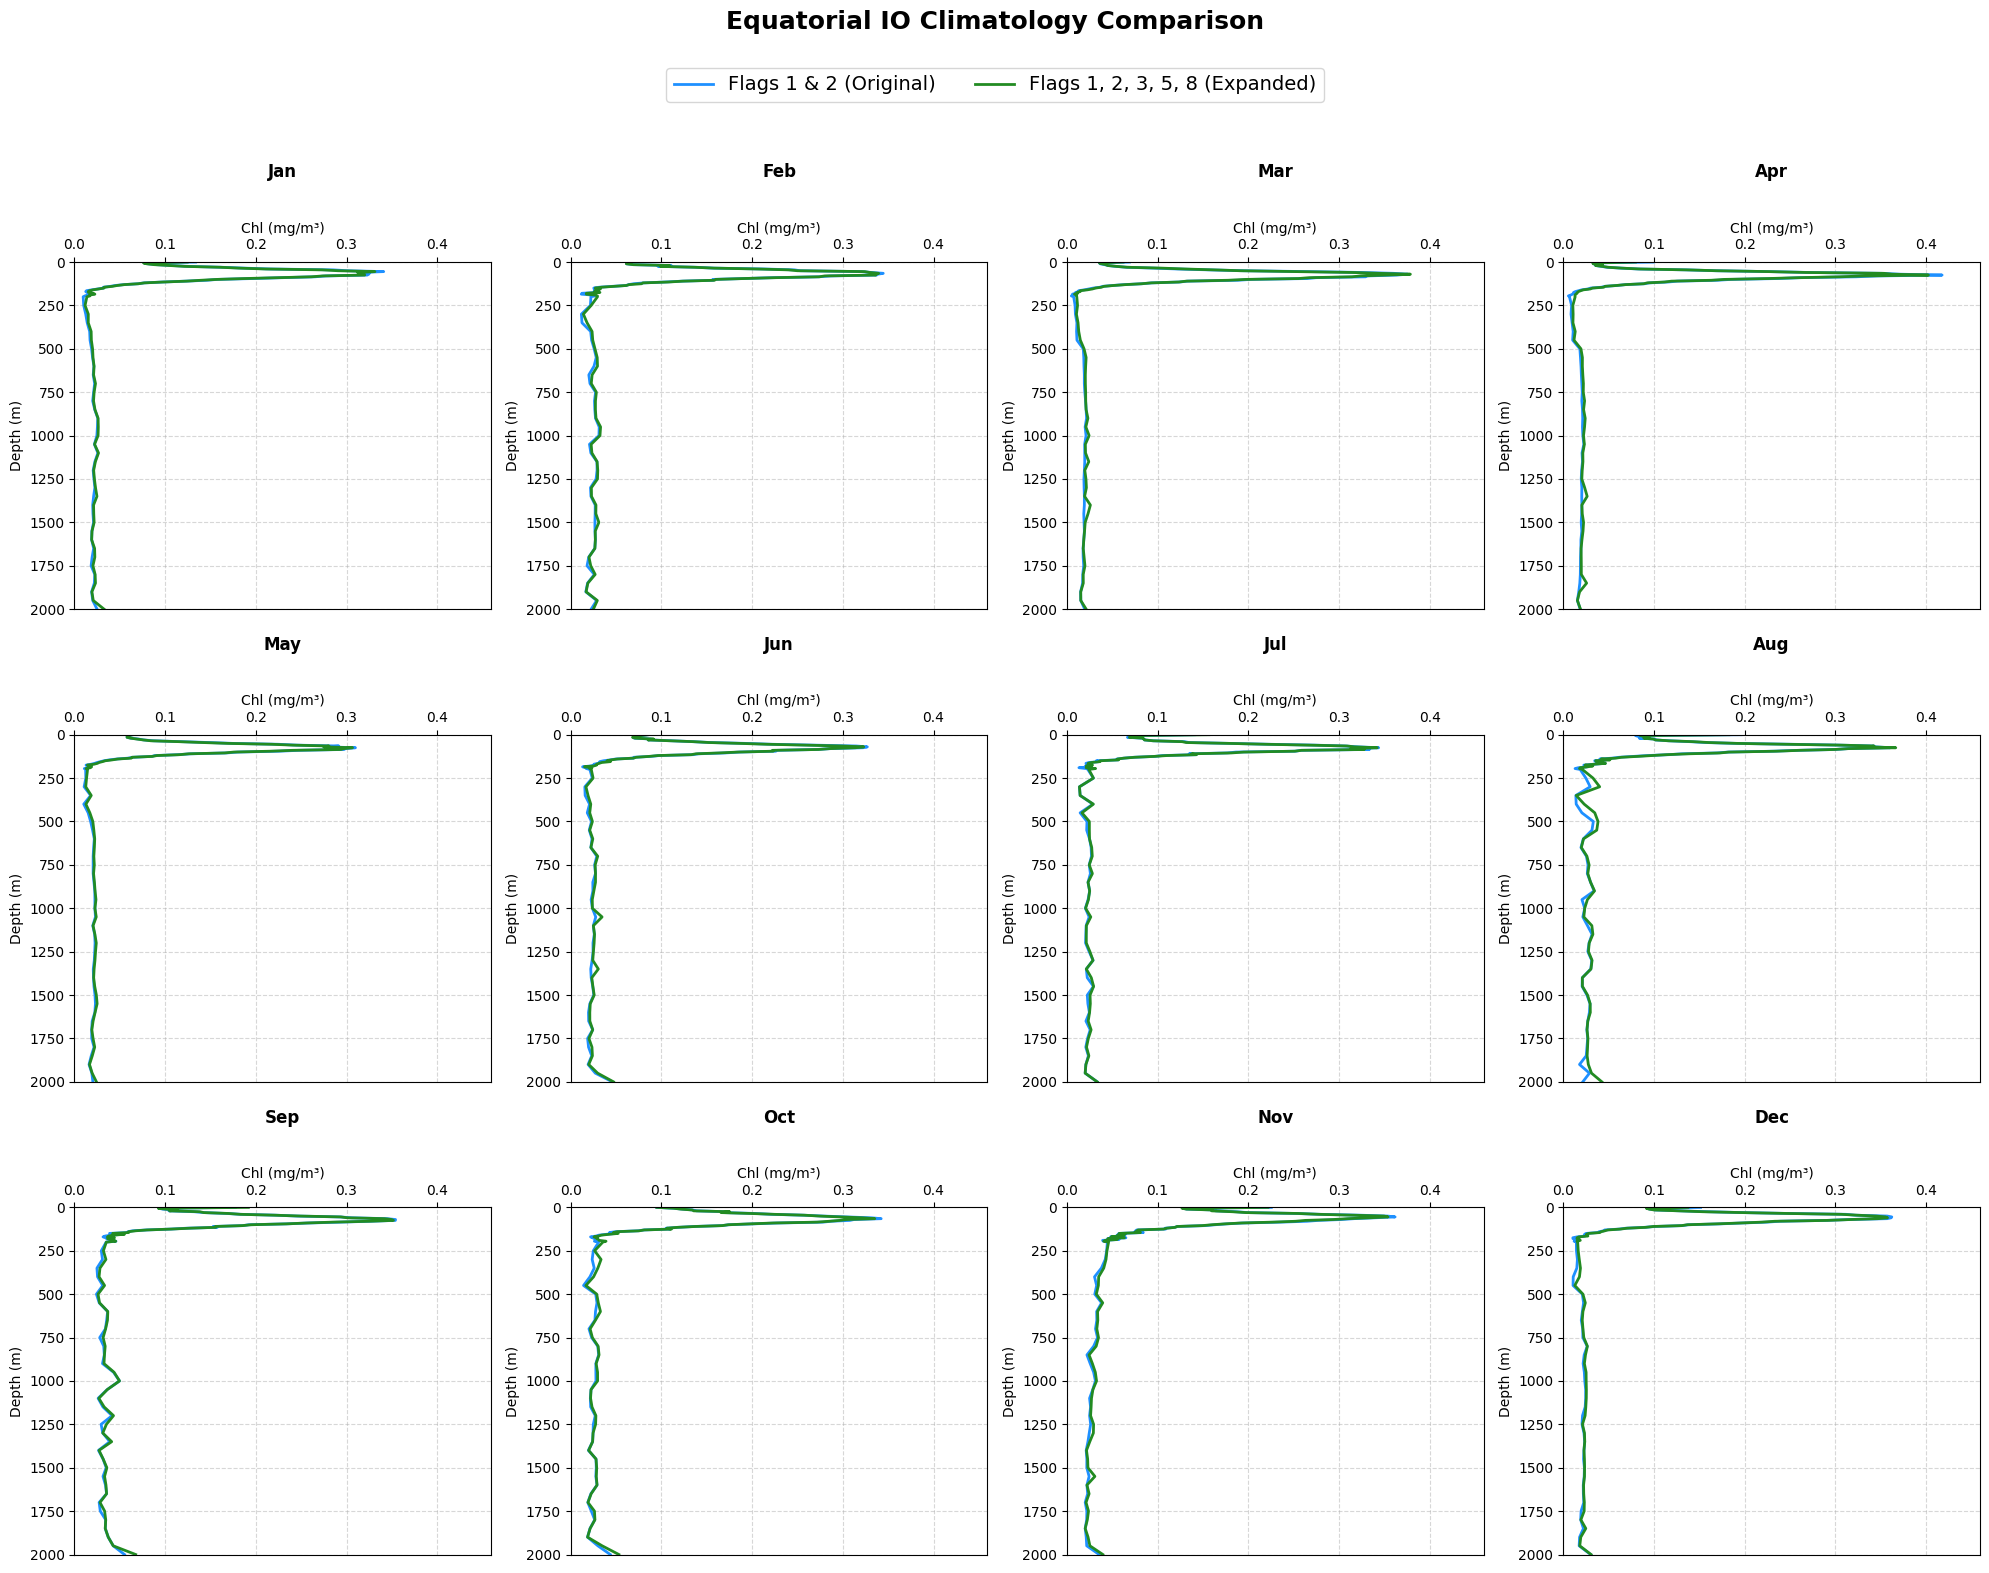

--------------------------------------------------


In [ ]:


# 1. Define the file configurations for all 3 regions
comparison_configs = {
    "Arabian_Sea": {
        "orig_path": "/content/Arabian_Sea_Climatology.csv",
        "f3_path": "climatology_expanded/Arabian_Sea_Climatology_Flag3.csv"
    },
    "Bay_of_Bengal": {
        "orig_path": "/content/Bay_of_Bengal_Climatology.csv",
        "f3_path": "climatology_expanded/Bay_of_Bengal_Climatology_Flag3.csv"
    },
    "Equatorial_IO": {
        "orig_path": "/content/Equatorial_IO_Climatology.csv",
        "f3_path": "climatology_expanded/Equatorial_IO_Climatology_Flag3.csv"
    }
}

# 2. Plotting parameters
color_orig = '#1E90FF'  # Dodger Blue (Original Flags 1 & 2)
color_f3 = '#228B22'    # Forest Green (Expanded Flags 1,2,3,5,8)

# 3. Loop through each region and generate its comparison chart
for region, paths in comparison_configs.items():
    # Verify both files exist before attempting to plot
    if not os.path.exists(paths["orig_path"]) or not os.path.exists(paths["f3_path"]):
        print(f"Skipping {region}: One or both CSV files are missing.")
        continue

    print(f"Generating comparison plot for {region}...")

    # Load datasets
    df_orig = pd.read_csv(paths["orig_path"], index_col=0)
    df_f3 = pd.read_csv(paths["f3_path"], index_col=0)

    # Establish a shared maximum scale between both versions of this specific region
    x_max = max(df_orig.max().max(), df_f3.max().max()) * 1.1
    y_max = df_f3.index.max()

    # Initialize the figure grid
    fig, axes = plt.subplots(3, 4, figsize=(20, 16), sharex=False, sharey=False)
    axes = axes.flatten()

    for i in range(12):
        ax = axes[i]
        month_num = i + 1
        month_name = calendar.month_abbr[month_num]

        # Plot profiles if month data exists in columns
        if str(month_num) in df_orig.columns:
            ax.plot(df_orig[str(month_num)], df_orig.index, color=color_orig, linewidth=2)
        if str(month_num) in df_f3.columns:
            ax.plot(df_f3[str(month_num)], df_f3.index, color=color_f3, linewidth=2)

        # Enforce distinct labels and formatting for every subplot
        ax.xaxis.set_label_position('top')
        ax.xaxis.tick_top()
        ax.set_xlabel('Chl (mg/m³)')
        ax.set_ylabel('Depth (m)')

        # Apply the absolute locked scale limits
        ax.set_xlim(0, x_max)
        ax.set_ylim(y_max, 0)  # Standard oceanography layout: 0m at top

        # Explicitly turn on ticks for all subplots
        ax.tick_params(axis='both', which='both', top=True, labeltop=True, left=True, labelleft=True)
        ax.set_title(f"{month_name}", y=1.22, fontweight='bold')
        ax.grid(True, linestyle='--', alpha=0.5)

    # Global figure adjustments
    plt.suptitle(f"{region.replace('_', ' ')} Climatology Comparison", y=0.98, fontsize=18, fontweight='bold')

    # Dedicated overhead legend for the figure
    fig.legend(labels=['Flags 1 & 2 (Original)', 'Flags 1, 2, 3, 5, 8 (Expanded)'],
               loc='upper center',
               bbox_to_anchor=(0.5, 0.95),
               ncol=2,
               fontsize=14,
               frameon=True)

    plt.tight_layout(rect=[0, 0, 1, 0.92])
    plt.show()
    print("-" * 50)

In [ ]:


# Define your unzipped folder paths (adjust names if they differ slightly)
regions = {
    "Arabian Sea": "fixed Arabian Sea chl bioargo",
    "Bay of Bengal": "fixed Bay_of_Bengal chl bioargo",
    "Equatorial IO": "fixed Equatorial_IO chl bioargo"
}

# Standard Argo NetCDF variable names for Photosynthetically Active Radiation
par_variable_keys = ['PAR', 'DOWNWELLING_PAR', 'PAR_ADJUSTED']

print("🔍 Scanning floats for Photosynthetically Active Radiation (PAR)...\n")

for region_name, base_dir in regions.items():
    if not os.path.exists(base_dir):
        print(f"⚠️ Folder '{base_dir}' not found for {region_name}. Skipping.")
        continue

    floats_with_par = set()

    for file in os.listdir(base_dir):
        if not file.endswith(".nc"):
            continue

        try:
            # Open only the coordinates and variable schemas to maximize speed
            with xr.open_dataset(os.path.join(base_dir, file), decode_times=False) as ds:
                # Check if any of our target PAR keys are present in the dataset
                has_par = any(key in ds.variables for key in par_variable_keys)

                if has_par:
                    # Extract the WMO float number from the filename (e.g., 'BR5906567_001.nc' -> '5906567')
                    # This splits by non-numeric indicators or assumes standard Argo naming
                    filename = os.path.basename(file)
                    # Standard Argo files often start with 'R', 'D', 'BR', 'BD' followed by WMO ID
                    clean_name = filename.replace("BR", "").replace("BD", "").replace("R", "").replace("D", "")
                    wmo_id = clean_name.split("_")[0]

                    if wmo_id.isdigit():
                        floats_with_par.add(wmo_id)
                    else:
                        # Fallback: use the first block of the filename
                        floats_with_par.add(filename.split("_")[0])

        except Exception as e:
            # Silent skip or log error if a specific file is corrupted
            continue

    # Print the sorted results for the location
    print(f"📍 {region_name}:")
    if floats_with_par:
        sorted_floats = sorted(list(floats_with_par))
        print(f"   Found {len(sorted_floats)} float(s) providing PAR data:")
        print(f"   📊 Floats: {', '.join(sorted_floats)}")
    else:
        print("   ❌ No floats in this directory contain PAR variables.")
    print("-" * 50)

🔍 Scanning floats for Photosynthetically Active Radiation (PAR)...

📍 Arabian Sea:
   Found 10 float(s) providing PAR data:
   📊 Floats: 1902594, 1902751, 2902753, 2902822, 2902823, 2902913, 2902914, 2902936, 4903619, 5907150
--------------------------------------------------
📍 Bay of Bengal:
   Found 1 float(s) providing PAR data:
   📊 Floats: 1902594
--------------------------------------------------
📍 Equatorial IO:
   Found 3 float(s) providing PAR data:
   📊 Floats: 3902490, 6990504, 7901023
--------------------------------------------------


In [ ]:


# Configuration
output_dir = "climatology_expanded"
os.makedirs(output_dir, exist_ok=True)

# Folder mappings
regions = {
    "Arabian_Sea": "fixed Arabian Sea chl bioargo",
    "Bay_of_Bengal": "fixed Bay_of_Bengal chl bioargo",
    "Equatorial_IO": "fixed Equatorial_IO chl bioargo"
}

# Target depth grid matching your Chlorophyll setup
std_grid = np.concatenate([np.arange(0, 205, 5), np.arange(250, 2050, 50)])

# Strictest QC flags only
accepted_flags = ['1', '2']

for region_name, base_dir in regions.items():
    if not os.path.exists(base_dir):
        print(f"Skipping {region_name}: Folder '{base_dir}' not found.")
        continue

    print(f"--- Processing PAR Climatology for {region_name} (Flags 1 & 2 Only) ---")
    monthly_data = {month: [] for month in range(1, 13)}

    for file in os.listdir(base_dir):
        if not file.endswith(".nc"): continue

        try:
            with xr.open_dataset(os.path.join(base_dir, file), decode_times=True) as ds:
                par_key = None
                qc_key = None

                # Prioritize adjusted variables
                if 'PAR_ADJUSTED' in ds.variables:
                    par_key = 'PAR_ADJUSTED'
                    qc_key = 'PAR_ADJUSTED_QC'
                elif 'PAR' in ds.variables:
                    par_key = 'PAR'
                    qc_key = 'PAR_QC'
                elif 'DOWNWELLING_PAR' in ds.variables:
                    par_key = 'DOWNWELLING_PAR'
                    qc_key = 'DOWNWELLING_PAR_QC'

                if par_key is None:
                    continue

                par = ds[par_key].values.copy()
                pres = ds['PRES_ADJUSTED'].values

                # Fallback to standard QC if adjusted QC array isn't explicitly there
                if qc_key not in ds.variables and 'PAR_QC' in ds.variables:
                    qc_key = 'PAR_QC'

                if qc_key in ds.variables:
                    qc = ds[qc_key].values.astype(str)
                    mask = np.isin(qc, accepted_flags)
                    par[~mask] = np.nan

                # Physical constraint: Remove instrument noise/negative values at depth
                par[par < 0] = np.nan

                time = ds['JULD'].values

                for i in range(ds.dims['N_PROF']):
                    month = pd.to_datetime(time[i]).month
                    p = pres[i, :]
                    par_profile = par[i, :]

                    if np.sum(~np.isnan(par_profile)) > 3:
                        # Grid the light data.
                        # right=0.0 forces absolute darkness below the photic zone.
                        interp_par = np.interp(std_grid, p, par_profile, left=np.nan, right=0.0)
                        monthly_data[month].append(interp_par)

        except Exception as e:
            print(f"Skipping file {file} in {region_name}: {e}")

    # Calculate Monthly Means and Export
    monthly_means = {}
    for m, data in monthly_data.items():
        if data:
            monthly_means[m] = np.nanmean(data, axis=0)
        else:
            monthly_means[m] = np.zeros(len(std_grid)) * np.nan

    df = pd.DataFrame(monthly_means, index=std_grid)
    output_file = f"{output_dir}/{region_name}_PAR_Climatology.csv"
    df.to_csv(output_file)
    print(f"✅ Saved baseline PAR Climatology to: {output_file}\n")

--- Processing PAR Climatology for Arabian_Sea (Flags 1 & 2 Only) ---


/tmp/ipykernel_548/2519462134.py:70: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  for i in range(ds.dims['N_PROF']):
/tmp/ipykernel_548/2519462134.py:70: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  for i in range(ds.dims['N_PROF']):
/tmp/ipykernel_548/2519462134.py:70: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  for i in range(ds.dims['N_PROF']):
/tmp/ipykernel_548/2519462134.py:70: Fut

✅ Saved baseline PAR Climatology to: climatology_expanded/Arabian_Sea_PAR_Climatology.csv

--- Processing PAR Climatology for Bay_of_Bengal (Flags 1 & 2 Only) ---


/tmp/ipykernel_548/2519462134.py:70: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  for i in range(ds.dims['N_PROF']):
/tmp/ipykernel_548/2519462134.py:88: RuntimeWarning: Mean of empty slice
  monthly_means[m] = np.nanmean(data, axis=0)


✅ Saved baseline PAR Climatology to: climatology_expanded/Bay_of_Bengal_PAR_Climatology.csv

--- Processing PAR Climatology for Equatorial_IO (Flags 1 & 2 Only) ---


/tmp/ipykernel_548/2519462134.py:70: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  for i in range(ds.dims['N_PROF']):
/tmp/ipykernel_548/2519462134.py:70: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  for i in range(ds.dims['N_PROF']):
/tmp/ipykernel_548/2519462134.py:70: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  for i in range(ds.dims['N_PROF']):


✅ Saved baseline PAR Climatology to: climatology_expanded/Equatorial_IO_PAR_Climatology.csv



/tmp/ipykernel_548/2519462134.py:88: RuntimeWarning: Mean of empty slice
  monthly_means[m] = np.nanmean(data, axis=0)


In [ ]:


output_dir = "climatology_expanded"
os.makedirs(output_dir, exist_ok=True)

regions = {
    "Arabian_Sea": "fixed Arabian Sea chl bioargo",
    "Bay_of_Bengal": "fixed Bay_of_Bengal chl bioargo",
    "Equatorial_IO": "fixed Equatorial_IO chl bioargo"
}

std_grid = np.concatenate([np.arange(0, 205, 5), np.arange(250, 2050, 50)])
accepted_flags = ['1', '2']

for region_name, base_dir in regions.items():
    if not os.path.exists(base_dir):
        print(f"Skipping {region_name}: Folder '{base_dir}' not found.")
        continue

    print(f"--- Re-processing PAR for {region_name} (Fixing Discontinuity) ---")
    monthly_data = {month: [] for month in range(1, 13)}

    for file in os.listdir(base_dir):
        if not file.endswith(".nc"): continue

        try:
            with xr.open_dataset(os.path.join(base_dir, file), decode_times=True) as ds:
                par_key = None
                qc_key = None

                if 'PAR_ADJUSTED' in ds.variables:
                    par_key = 'PAR_ADJUSTED'; qc_key = 'PAR_ADJUSTED_QC'
                elif 'PAR' in ds.variables:
                    par_key = 'PAR'; qc_key = 'PAR_QC'
                elif 'DOWNWELLING_PAR' in ds.variables:
                    par_key = 'DOWNWELLING_PAR'; qc_key = 'DOWNWELLING_PAR_QC'

                if par_key is None: continue

                par = ds[par_key].values.copy()
                pres = ds['PRES_ADJUSTED'].values

                if qc_key not in ds.variables and 'PAR_QC' in ds.variables:
                    qc_key = 'PAR_QC'

                if qc_key in ds.variables:
                    qc = ds[qc_key].values.astype(str)
                    mask = np.isin(qc, accepted_flags)
                    par[~mask] = np.nan

                par[par < 0] = np.nan
                time = ds['JULD'].values

                for i in range(ds.dims['N_PROF']):
                    month = pd.to_datetime(time[i]).month
                    p = pres[i, :]
                    par_profile = par[i, :]

                    # Drop NaNs before interpolating to prevent fragmented lines
                    valid_idx = ~np.isnan(par_profile) & ~np.isnan(p)

                    # We need at least 5 clean points to establish a realistic exponential decay curve
                    if np.sum(valid_idx) > 5:
                        clean_p = p[valid_idx]
                        clean_par = par_profile[valid_idx]

                        # Sort by depth to ensure monotonic interpolation
                        sort_idx = np.argsort(clean_p)
                        clean_p = clean_p[sort_idx]
                        clean_par = clean_par[sort_idx]

                        # Force an anchor: if the shallowest point is within the top 10m,
                        # extrapolate it cleanly up to 0m so the line connects to the surface
                        if clean_p[0] <= 10 and clean_p[0] > 0:
                            clean_p = np.insert(clean_p, 0, 0.0)
                            clean_par = np.insert(clean_par, 0, clean_par[0])

                        # Linearly interpolate gaps, and force right (deep water) to 0.0
                        interp_par = np.interp(std_grid, clean_p, clean_par, left=np.nan, right=0.0)
                        monthly_data[month].append(interp_par)

        except Exception as e:
            continue

    # Calculate Monthly Means
    monthly_means = {}
    for m, data in monthly_data.items():
        if data:
            # Using nanmean ignores profiles that are missing data for this specific month
            monthly_means[m] = np.nanmean(data, axis=0)
        else:
            monthly_means[m] = np.zeros(len(std_grid)) * np.nan

    df = pd.DataFrame(monthly_means, index=std_grid)
    output_file = f"{output_dir}/{region_name}_PAR_Climatology.csv"
    df.to_csv(output_file)
    print(f"✅ Saved continuous PAR Climatology to: {output_file}\n")

--- Re-processing PAR for Arabian_Sea (Fixing Discontinuity) ---


/tmp/ipykernel_548/1244268953.py:57: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  for i in range(ds.dims['N_PROF']):
/tmp/ipykernel_548/1244268953.py:57: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  for i in range(ds.dims['N_PROF']):
/tmp/ipykernel_548/1244268953.py:57: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  for i in range(ds.dims['N_PROF']):
/tmp/ipykernel_548/1244268953.py:57: Fut

✅ Saved continuous PAR Climatology to: climatology_expanded/Arabian_Sea_PAR_Climatology.csv

--- Re-processing PAR for Bay_of_Bengal (Fixing Discontinuity) ---


/tmp/ipykernel_548/1244268953.py:57: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  for i in range(ds.dims['N_PROF']):


✅ Saved continuous PAR Climatology to: climatology_expanded/Bay_of_Bengal_PAR_Climatology.csv

--- Re-processing PAR for Equatorial_IO (Fixing Discontinuity) ---


/tmp/ipykernel_548/1244268953.py:57: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  for i in range(ds.dims['N_PROF']):
/tmp/ipykernel_548/1244268953.py:57: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  for i in range(ds.dims['N_PROF']):
/tmp/ipykernel_548/1244268953.py:57: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  for i in range(ds.dims['N_PROF']):


✅ Saved continuous PAR Climatology to: climatology_expanded/Equatorial_IO_PAR_Climatology.csv



Generating clean PAR vs Chl relationship plots for Arabian_Sea...


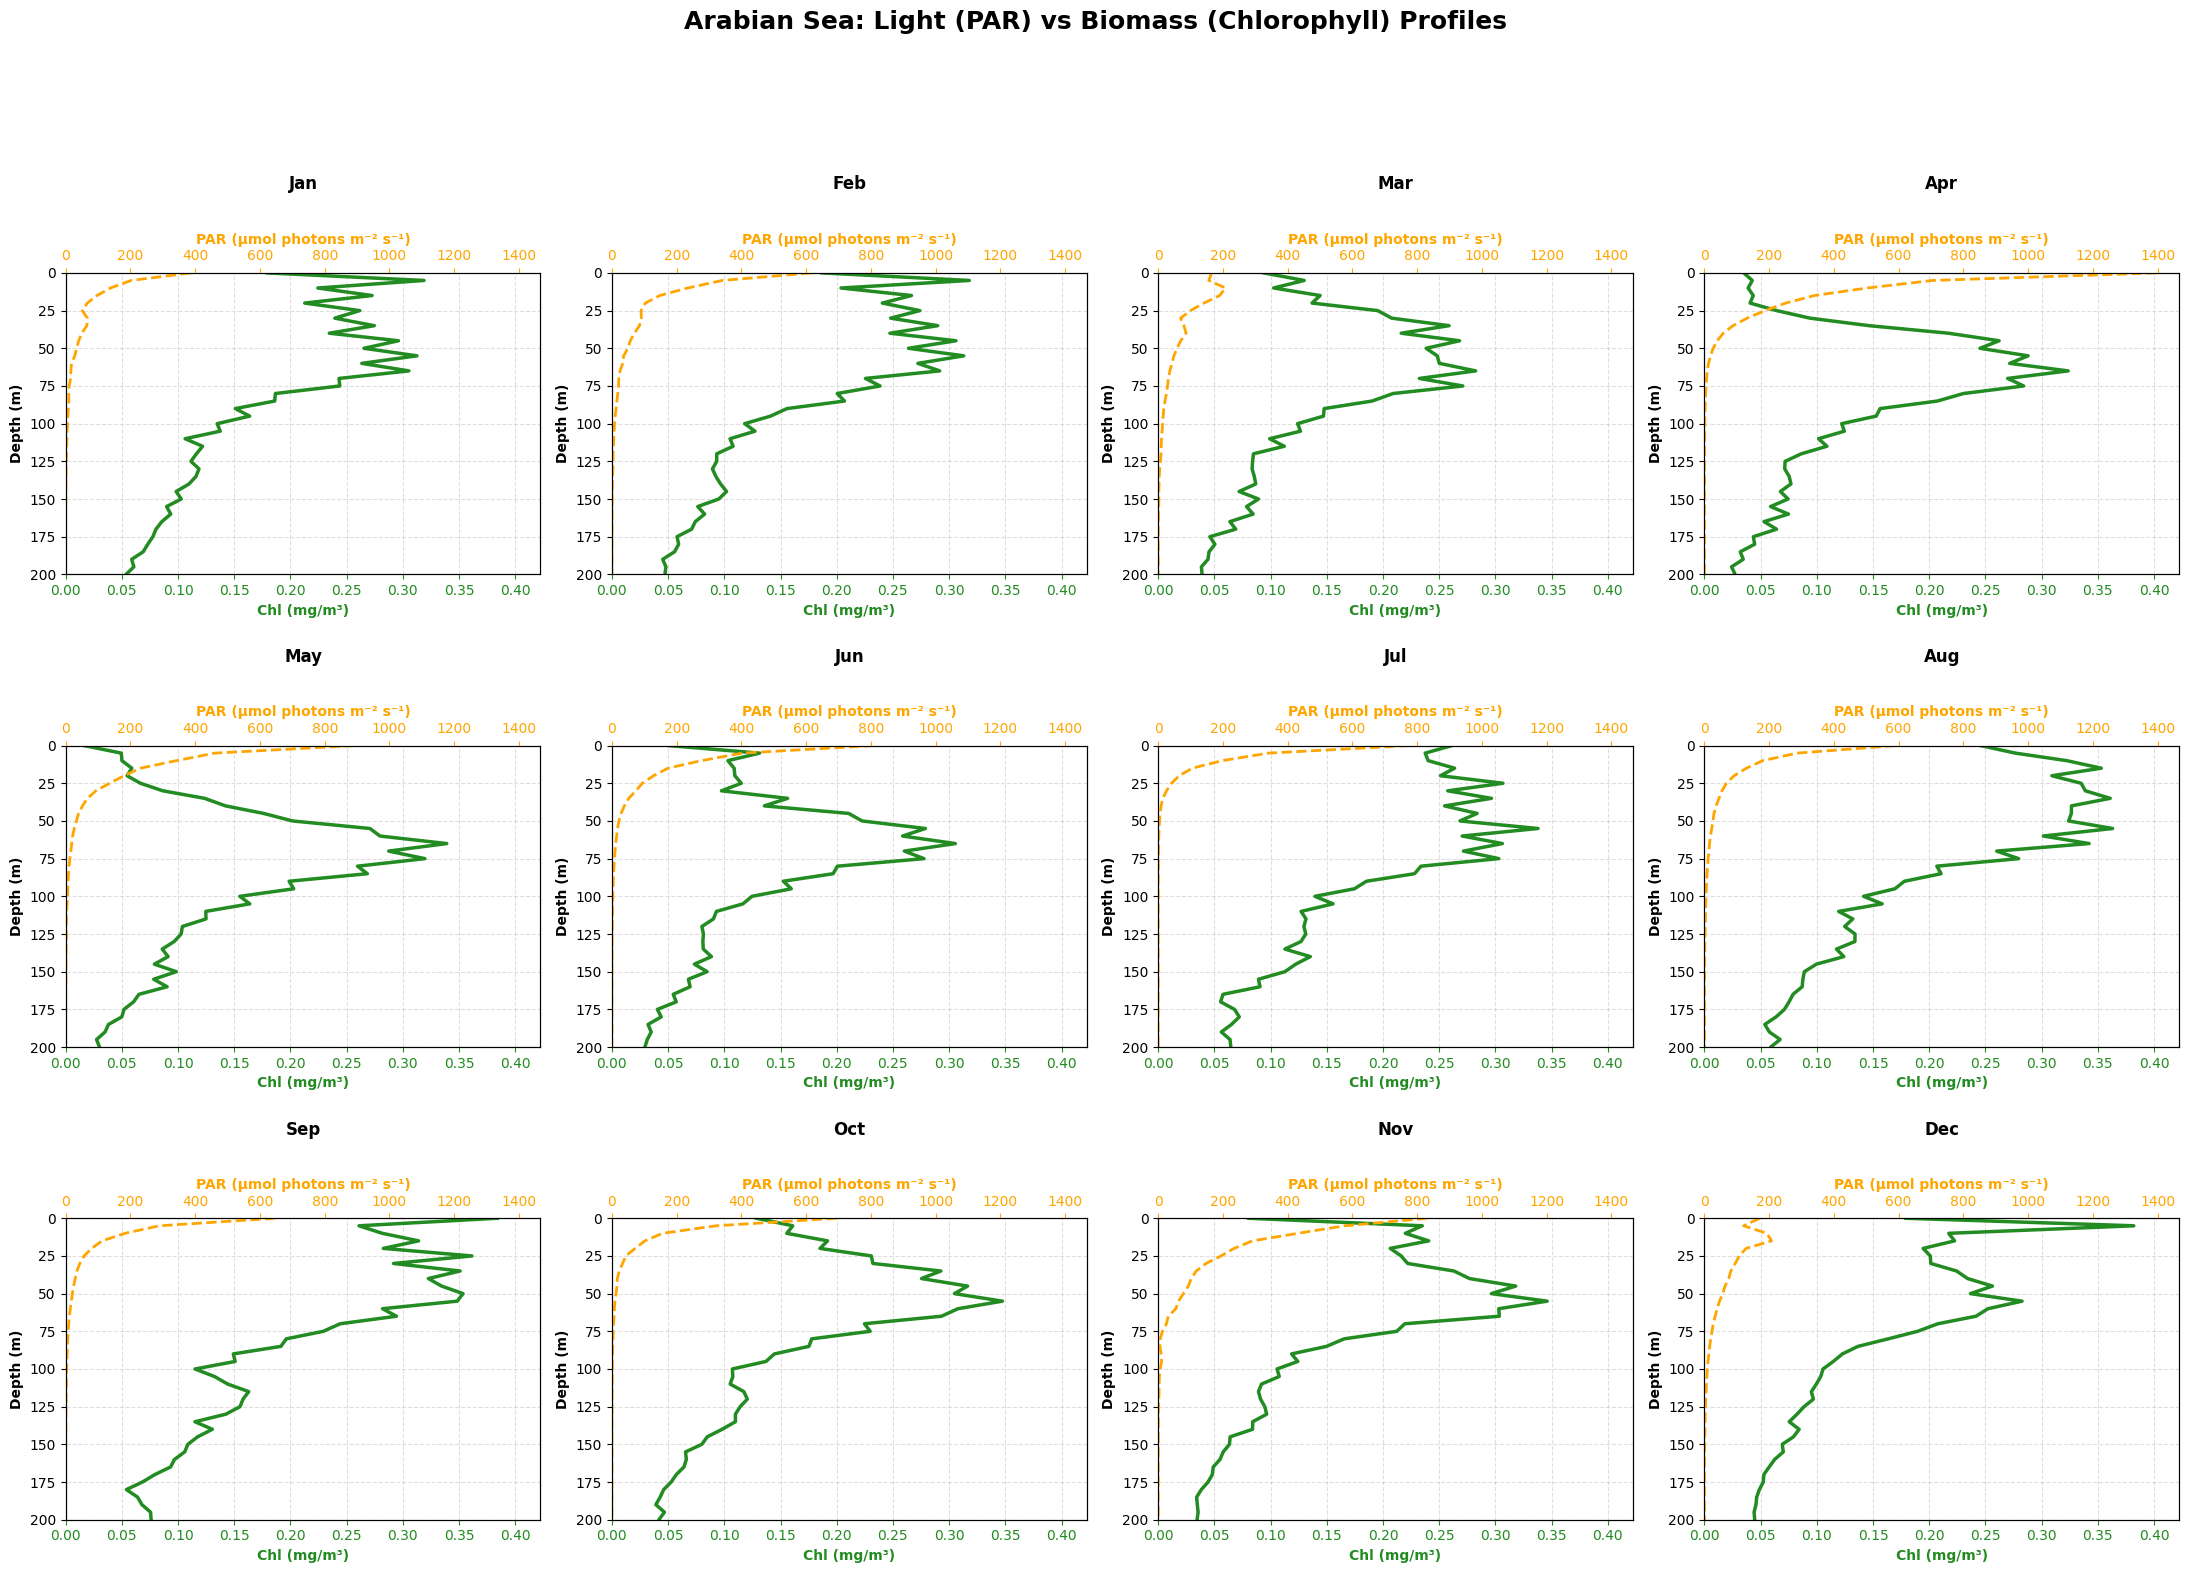

----------------------------------------------------------------------
Generating clean PAR vs Chl relationship plots for Bay_of_Bengal...


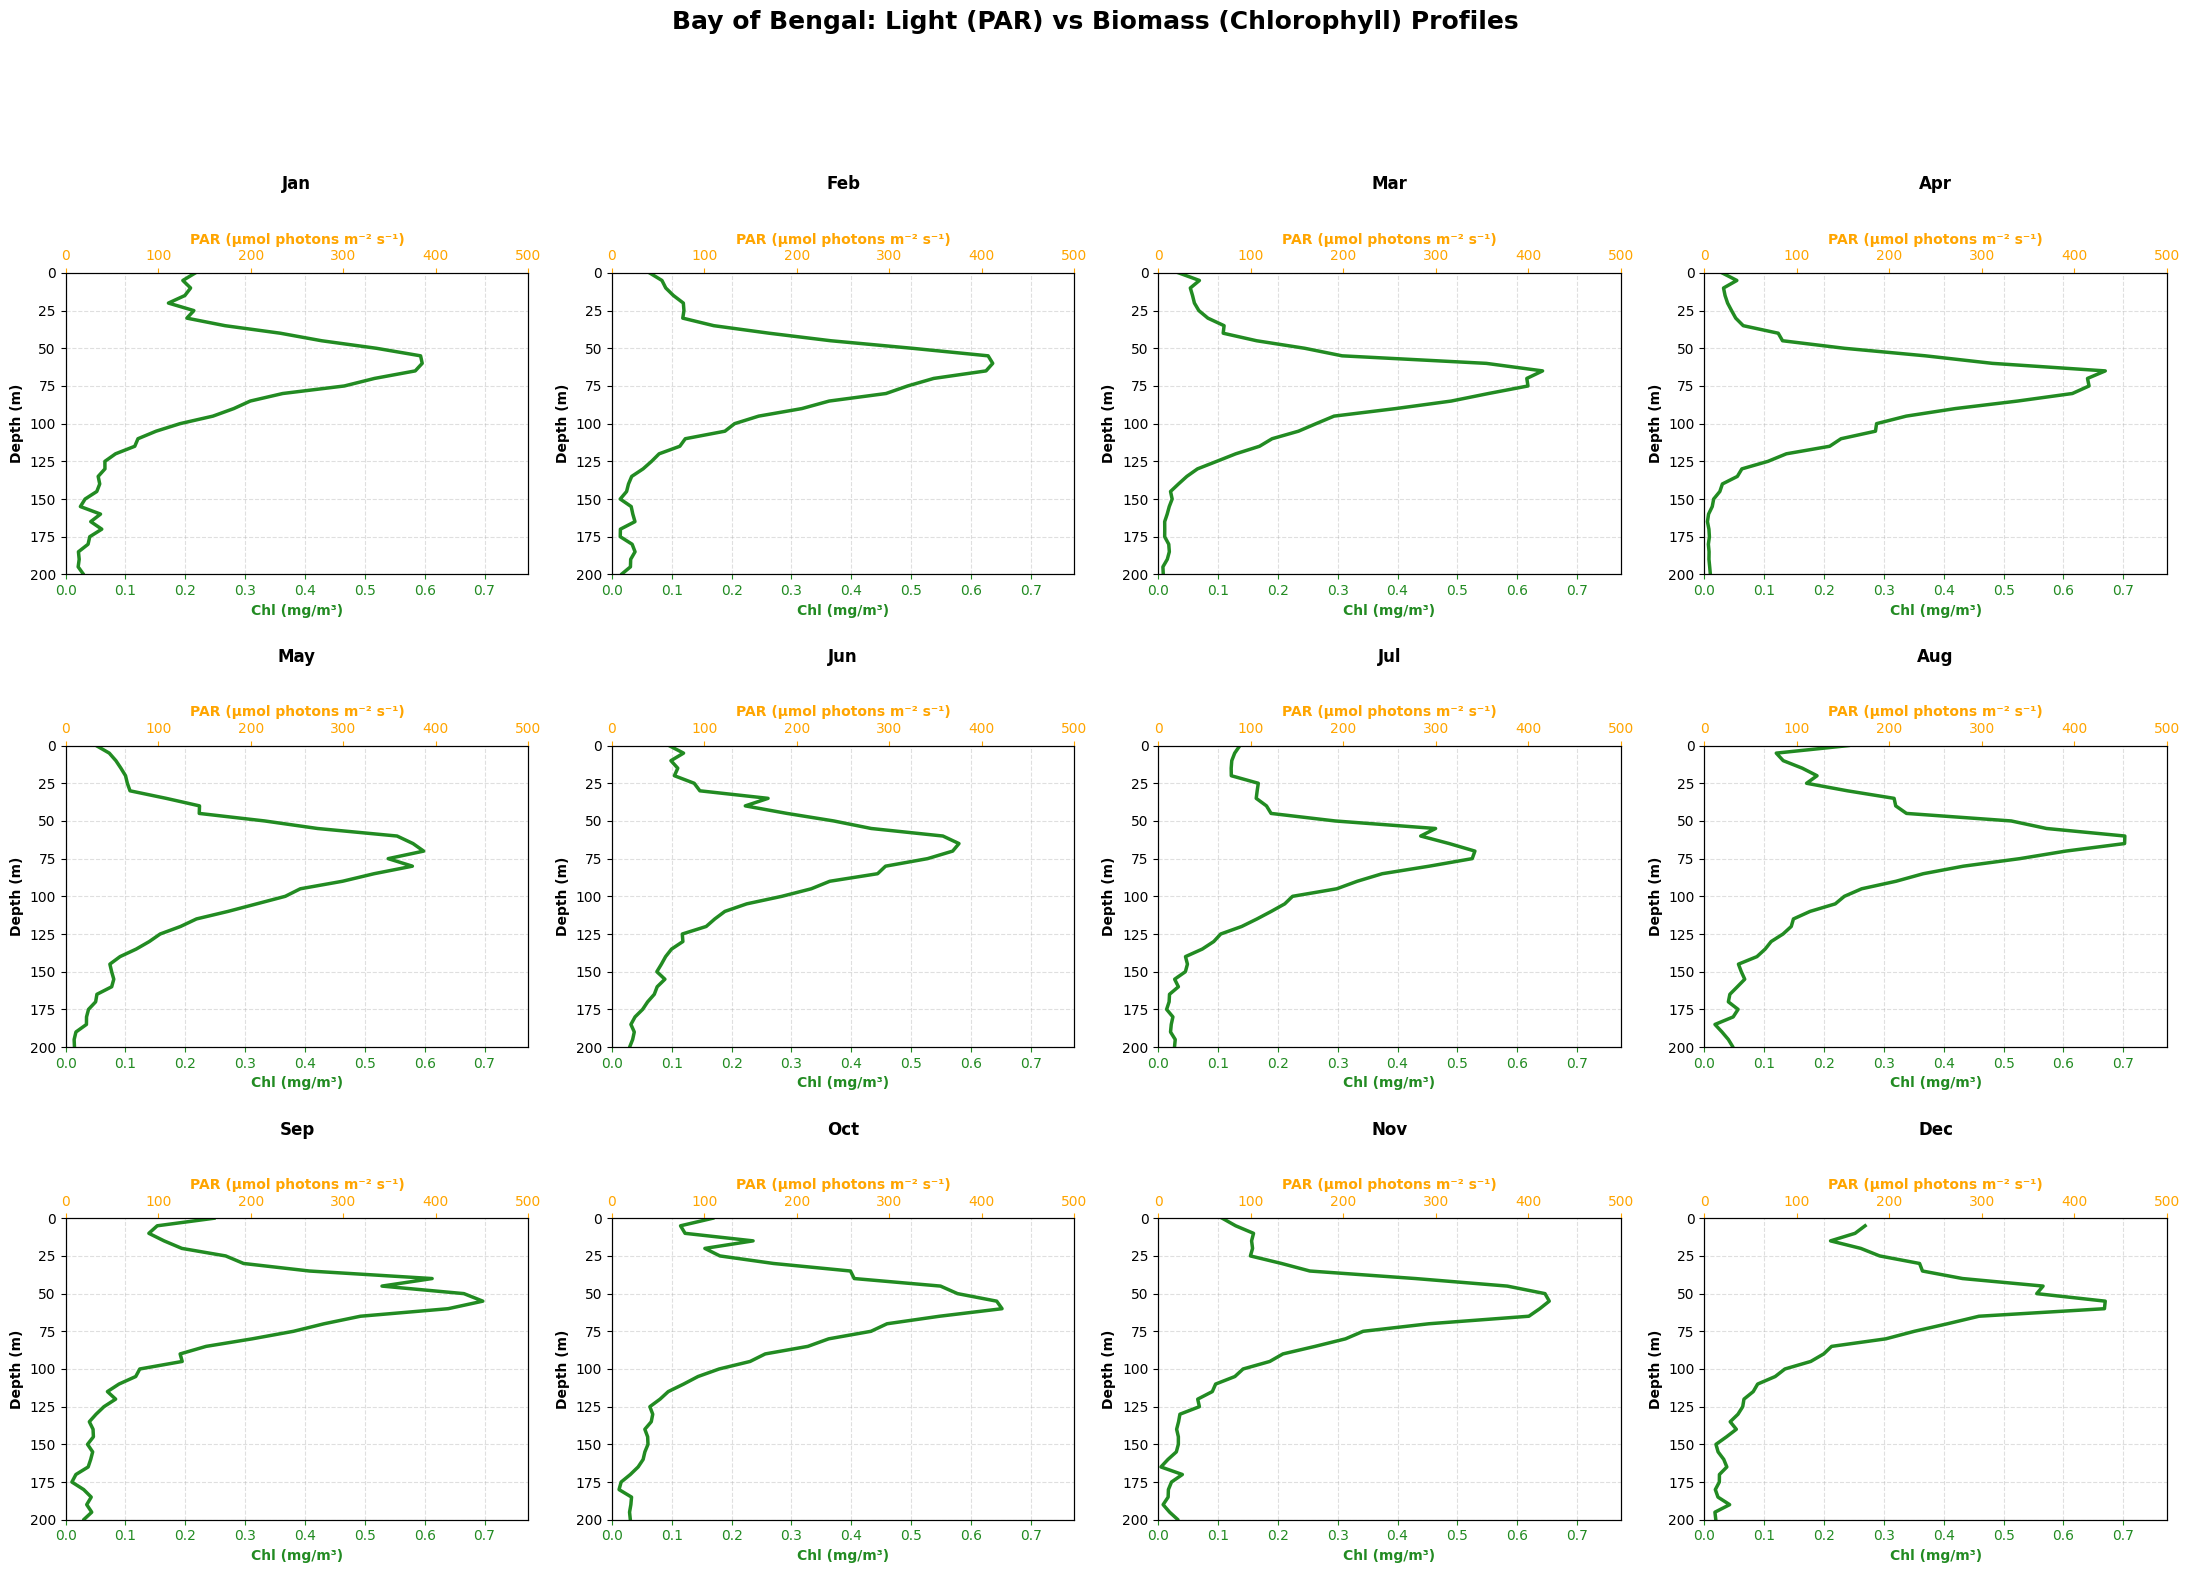

----------------------------------------------------------------------
Generating clean PAR vs Chl relationship plots for Equatorial_IO...


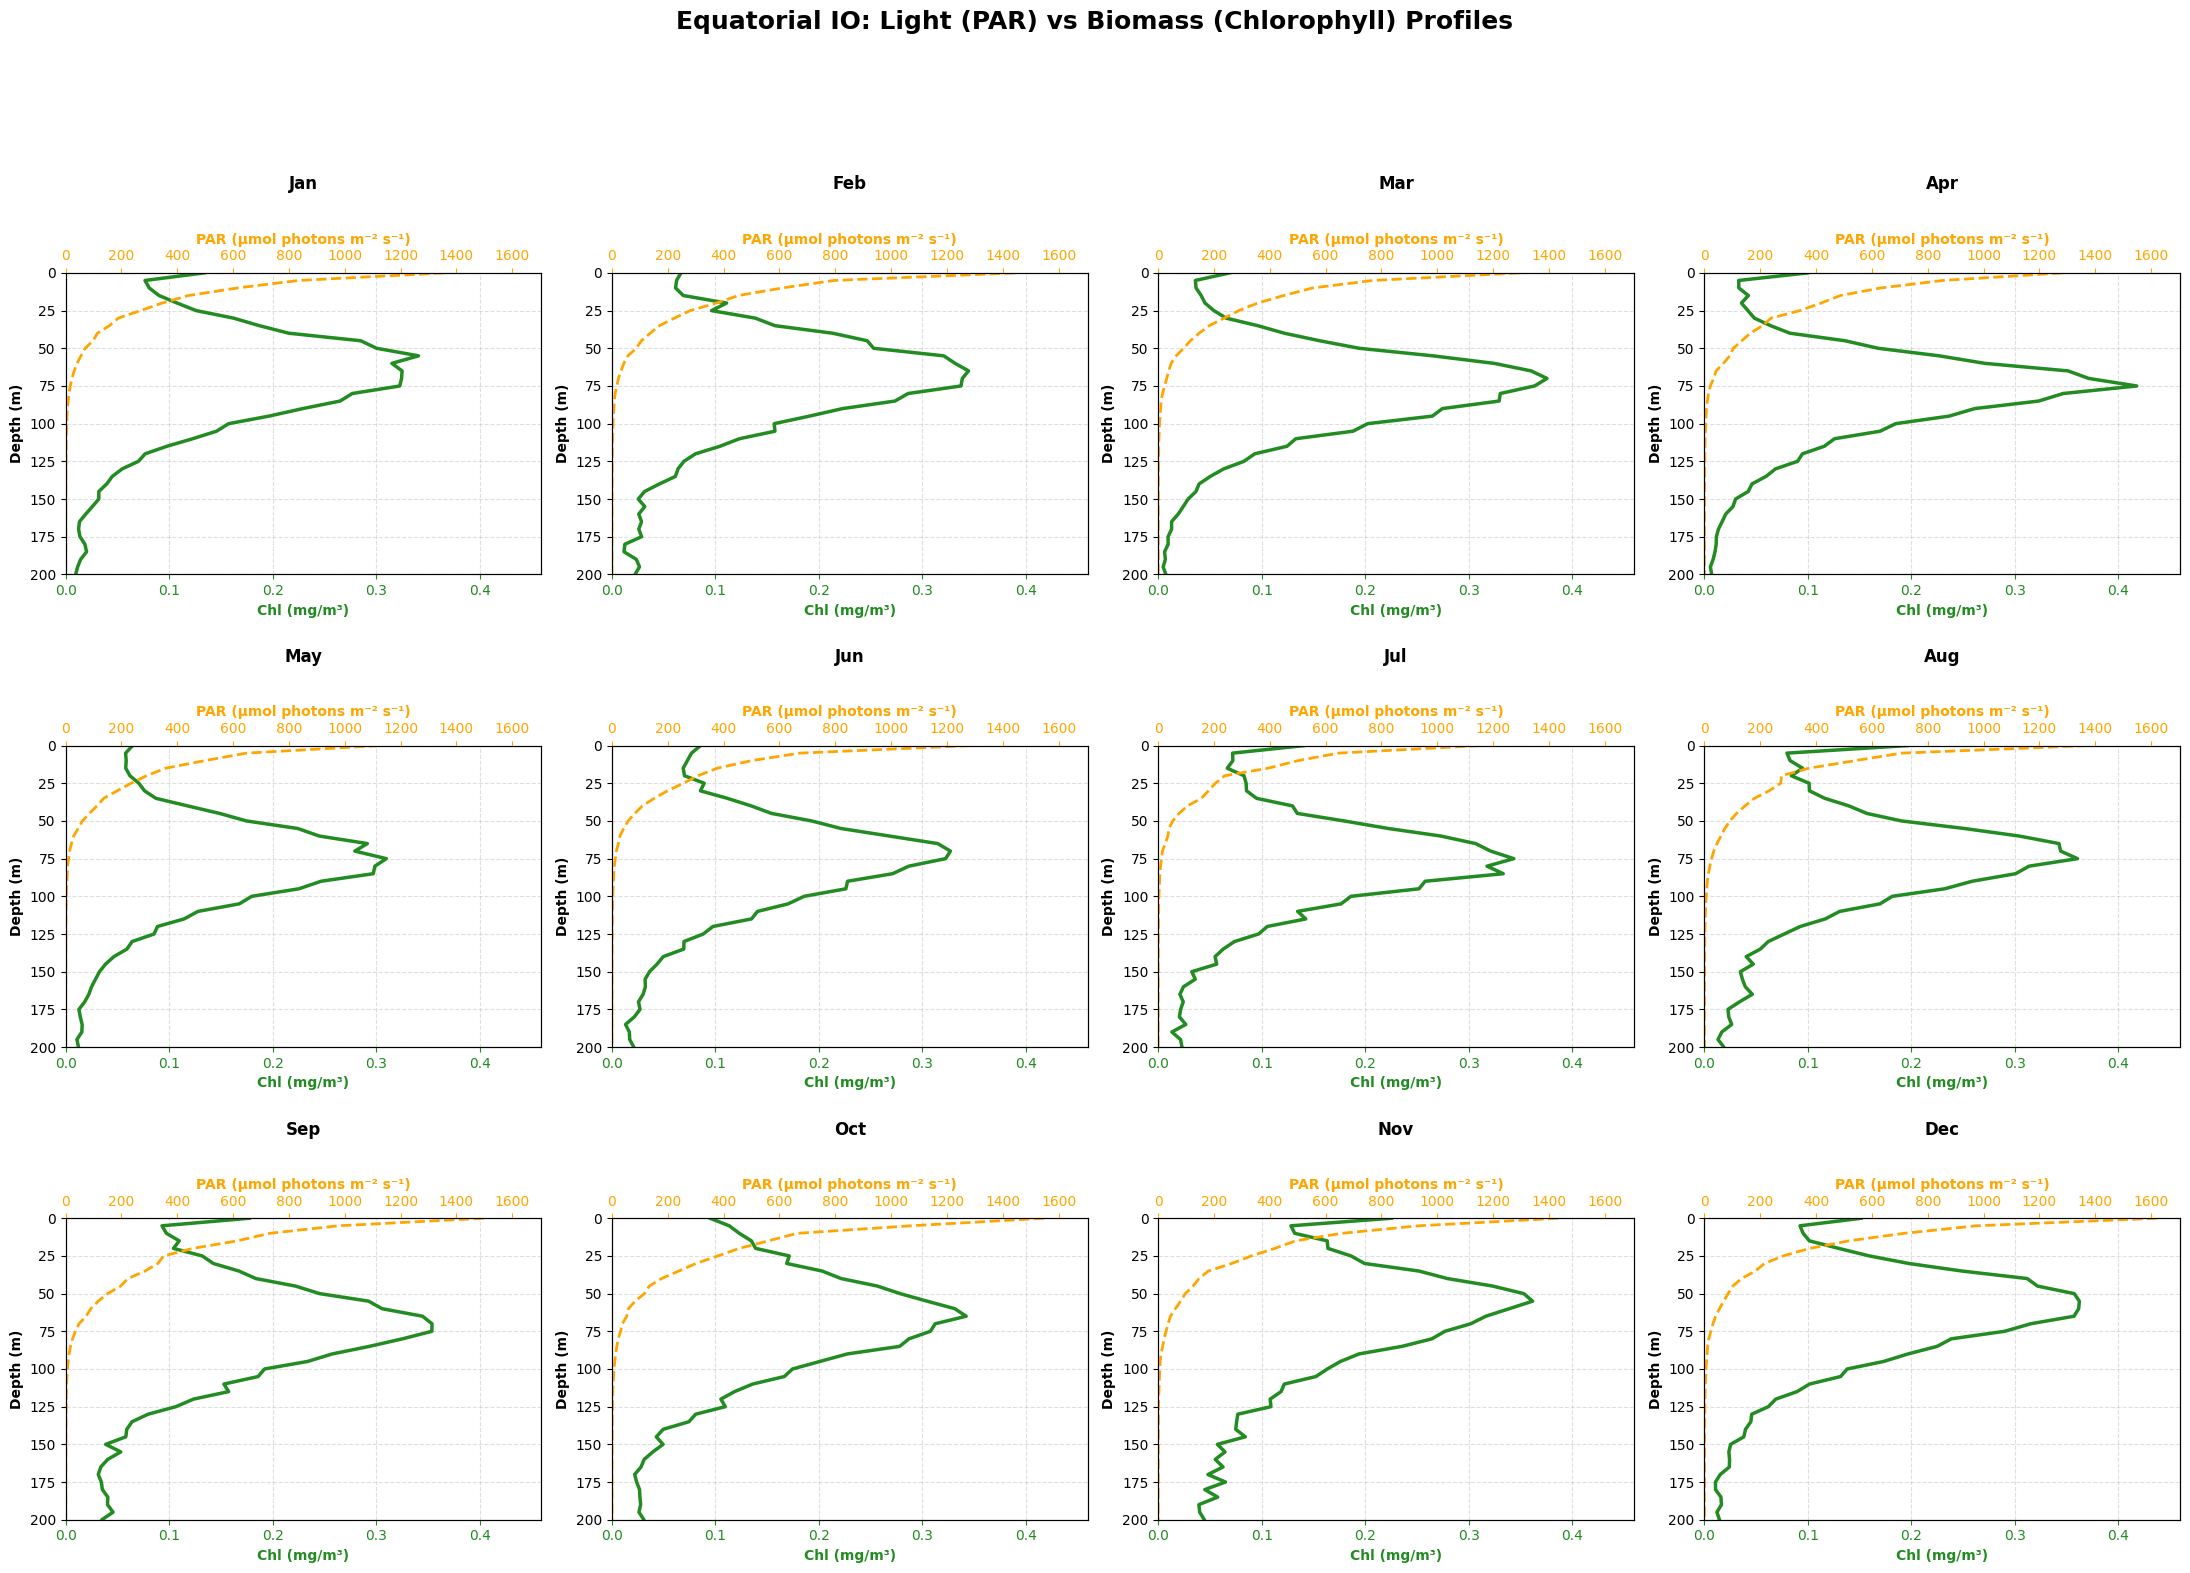

----------------------------------------------------------------------


In [ ]:

# 1. File configurations for the baseline datasets (Flags 1 & 2)
regions_config = {
    "Arabian_Sea": {
        "chl_path": "/content/Arabian_Sea_Climatology.csv",
        "par_path": "climatology_expanded/Arabian_Sea_PAR_Climatology.csv"
    },
    "Bay_of_Bengal": {
        "chl_path": "/content/Bay_of_Bengal_Climatology.csv",
        "par_path": "climatology_expanded/Bay_of_Bengal_PAR_Climatology.csv"
    },
    "Equatorial_IO": {
        "chl_path": "/content/Equatorial_IO_Climatology.csv",
        "par_path": "climatology_expanded/Equatorial_IO_PAR_Climatology.csv"
    }
}

# 2. Color Scheme Configuration
color_chl = '#228B22'  # Forest Green
color_par = '#FFA500'  # Gold / Orange

for region, paths in regions_config.items():
    if not os.path.exists(paths["chl_path"]) or not os.path.exists(paths["par_path"]):
        print(f"Skipping {region}: Missing either Chlorophyll or PAR baseline file.")
        continue

    print(f"Generating clean PAR vs Chl relationship plots for {region}...")

    df_chl = pd.read_csv(paths["chl_path"], index_col=0)
    df_par = pd.read_csv(paths["par_path"], index_col=0)

    # --- CRITICAL FIX: Handle NaN-only Data Frames ---
    # Calculate max while ignoring NaNs
    raw_chl_max = df_chl.max().max()
    raw_par_max = df_par.max().max()

    # Fallback to defaults if the entire region lacks data for either variable
    chl_max = raw_chl_max * 1.1 if pd.notna(raw_chl_max) else 2.0
    par_max = raw_par_max * 1.05 if pd.notna(raw_par_max) else 500.0

    # Focus on the upper 200m where solar radiation interacts with biological activity
    display_depth_max = 200

    fig, axes = plt.subplots(3, 4, figsize=(22, 16), sharex=False, sharey=False)
    axes = axes.flatten()

    for i in range(12):
        ax_chl = axes[i]
        month_num = i + 1
        month_name = calendar.month_abbr[month_num]
        month_str = str(month_num)

        # Create a twin axis for PAR sharing the same depth (Y-axis)
        ax_par = ax_chl.twiny()

        # Plot Chlorophyll (Bottom Axis - Green Solid Line)
        if month_str in df_chl.columns and not df_chl[month_str].isna().all():
            ax_chl.plot(df_chl[month_str], df_chl.index, color=color_chl, linewidth=2.5, label='Chl')

        # Plot PAR (Top Axis - Gold/Orange Dashed Line)
        # ONLY plot if the entire month isn't completely empty NaNs
        if month_str in df_par.columns and not df_par[month_str].isna().all():
            ax_par.plot(df_par[month_str], df_par.index, color=color_par, linewidth=2, linestyle='--', label='PAR')

        # Configure Chlorophyll Axis (Bottom)
        ax_chl.set_xlabel('Chl (mg/m³)', color=color_chl, fontweight='bold')
        ax_chl.tick_params(axis='x', colors=color_chl)
        ax_chl.set_xlim(0, chl_max)

        # Configure PAR Axis (Top)
        ax_par.set_xlabel('PAR (µmol photons m⁻² s⁻¹)', color=color_par, fontweight='bold')
        ax_par.tick_params(axis='x', colors=color_par)
        ax_par.set_xlim(0, par_max)

        # Enforce distinct, fully structured Y-axis (Depth) settings for every subplot
        ax_chl.set_ylabel('Depth (m)', fontweight='bold')
        ax_chl.set_ylim(display_depth_max, 0)  # Surface (0m) stays cleanly at the top
        ax_chl.tick_params(axis='y', left=True, labelleft=True)

        ax_chl.set_title(f"{month_name}", y=1.25, fontweight='bold', fontsize=12)
        ax_chl.grid(True, linestyle='--', alpha=0.4)

    plt.suptitle(f"{region.replace('_', ' ')}: Light (PAR) vs Biomass (Chlorophyll) Profiles",
                 y=0.98, fontsize=18, fontweight='bold')

    plt.tight_layout(rect=[0, 0, 1, 0.92])
    plt.show()
    print("-" * 70)